In [4]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD

os.chdir("/mnt/data/ProjetMeteo/Analyse_Meteo")
Path.cwd()

raw_french_temp_array = np.load("month_mean_serie.npy")

In [6]:
import pandas as pd

# ==============================================================================
# 1. PARSE THE RAW TEXT FILES
# ==============================================================================
# sep='\s+' instructs pandas to treat any amount of consecutive whitespace as a single delimiter.
# na_values=[-99.9, -99.90] captures the standard NOAA missing data flags.

# Load North Atlantic Oscillation
df_nao = pd.read_csv("demo_france/NAO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

# Load East Atlantic Pattern
df_ea = pd.read_csv("demo_france/EA.txt", sep='\s+', na_values=[-99.9, -99.90])

# ==============================================================================
# 2. STANDARDIZE THE COLUMNS
# ==============================================================================
# Ensure the columns are strictly named for accurate merging
df_nao.columns = ['Year', 'Month', 'NAO']
df_ea.columns = ['Year', 'Month', 'EA']

# ==============================================================================
# 3. MERGE INTO THE MASTER CLIMATE MATRIX
# ==============================================================================
# We perform an 'inner' merge on the Year and Month columns. 
# This strictly enforces temporal alignment. If a month is missing in one file, 
# it drops the row to prevent out-of-phase signal corruption.
df_climate = pd.merge(df_nao, df_ea, on=['Year', 'Month'], how='inner')

# ==============================================================================
# 4. BUILD THE CHRONOLOGICAL TIME INDEX
# ==============================================================================
# Convert the discrete Year and Month integer columns into a continuous DateTime object.
# We assign '01' as the day for every month to satisfy the DateTime requirement.
df_climate['Date'] = pd.to_datetime(
    df_climate['Year'].astype(str) + '-' + df_climate['Month'].astype(str) + '-01'
)

# Set the continuous Date vector as the strict mathematical index of the DataFrame
df_climate.set_index('Date', inplace=True)

# Drop the now redundant discrete temporal columns
df_climate.drop(columns=['Year', 'Month'], inplace=True)

# ==============================================================================
# 5. VERIFY MATRIX INTEGRITY
# ==============================================================================
print(df_climate.info())
print("\nFirst 5 rows:")
print(df_climate.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 915 entries, 1950-01-01 to 2026-03-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NAO     915 non-null    float64
 1   EA      915 non-null    float64
dtypes: float64(2)
memory usage: 21.4 KB
None

First 5 rows:
             NAO    EA
Date                  
1950-01-01  0.92 -2.71
1950-02-01  0.40  0.66
1950-03-01 -0.36  0.82
1950-04-01  0.73  0.28
1950-05-01 -0.59 -0.51


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_365596/45244839.py:10: SyntaxWarning: invalid escape sequence '\s'
  df_nao = pd.read_csv("demo_france/NAO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_365596/45244839.py:13: SyntaxWarning: invalid escape sequence '\s'
  df_ea = pd.read_csv("demo_france/EA.txt", sep='\s+', na_values=[-99.9, -99.90])


In [7]:
df_climate = df_climate[:912]
df_climate['raw'] = raw_french_temp_array
#df_climate['cycle'] = cycle_array

In [8]:
df_sca = pd.read_csv("demo_france/SCA.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

# Load East Atlantic Pattern
df_amo = pd.read_csv("demo_france/AMO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_365596/1385202438.py:1: SyntaxWarning: invalid escape sequence '\s'
  df_sca = pd.read_csv("demo_france/SCA.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_365596/1385202438.py:4: SyntaxWarning: invalid escape sequence '\s'
  df_amo = pd.read_csv("demo_france/AMO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)


In [9]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. DYNAMIC COLUMN MAPPING
# ==============================================================================
# Reset the index to ensure no data is hidden in the index structure
df_raw = df_sca
df_raw = df_raw.reset_index(drop=True)

# Dynamically assess the shape of the imported matrix
num_cols = df_raw.shape[1]

if num_cols == 14:
    # Condition A: The arbitrary index (0, 1, 2) was parsed as a data column
    df_raw.columns = ['Drop_Index', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw.drop(columns=['Drop_Index'])
elif num_cols == 13:
    # Condition B: The data parsed strictly as Year + 12 Months
    df_raw.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw.copy()
else:
    raise ValueError(f"Matrix Dimension Error: Expected 13 or 14 columns, but detected {num_cols}.")

# ==============================================================================
# 2. CLEANING THE DATA MATRIX
# ==============================================================================
# Remove the faulty row and replace placeholders
# We force 'Year' to numeric first to ensure strict equality checking
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
df_clean = df_clean.dropna(subset=['Year']) # Drop if the header row was imported as data
df_clean = df_clean[df_clean['Year'] != -9999]
df_clean = df_clean.replace(-9999.00, np.nan)

# ==============================================================================
# 3. STRUCTURAL TRANSFORMATION (WIDE TO LONG)
# ==============================================================================
# Melt the dataframe: Year remains the identifier, months become a variable column
df_long = df_clean.melt(id_vars=['Year'], var_name='Month', value_name='Target_Value')

# Map string months to integers for datetime conversion
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_long['Month_Num'] = df_long['Month'].map(month_map)

# ==============================================================================
# 4. TIME SERIES INDEXING
# ==============================================================================
# Construct standard Datetime objects (YYYY-MM-01)
# Ensure Year is strictly an integer string for the datetime parser
df_long['Date'] = pd.to_datetime(
    df_long['Year'].astype(int).astype(str) + '-' + 
    df_long['Month_Num'].astype(str) + '-01'
)

# Sort chronologically
df_ts = df_long.sort_values('Date')

# Set the Date as the index and isolate the single dimension
df_1d = df_ts.set_index('Date')[['Target_Value']]

# Drop the future unrecorded months
df_final = df_1d.dropna()


In [11]:
df_climate = df_climate[:905]
df_climate['AMO'] = df_amo[2][:905].values
df_climate['SCA'] = df_final.values
df_climate

,NAO,EA,raw,AMO,SCA
Date,,,,,
1950-01-01,0.9200,-2.71,2.148903,-0.03,0.78
1950-02-01,0.4000,0.66,5.969903,-0.13,-0.94
1950-03-01,-0.3600,0.82,7.083308,-0.16,-0.22
1950-04-01,0.7300,0.28,8.031222,-0.22,0.46
1950-05-01,-0.5900,-0.51,13.992700,-0.23,0.28
...,...,...,...,...,...
2025-01-01,-0.5224,2.70,4.451415,0.98,-0.72
2025-02-01,1.5958,0.65,5.495558,0.86,1.38
2025-03-01,0.2999,0.81,7.924747,0.75,-0.18


In [ ]:
from PyEMD import CEEMDAN
from scipy.fft import fft, fftfreq

def compute_dominant_period(time_series, sampling_interval=1.0):
    """
    Computes the dominant period of a discrete time series using the Fast Fourier Transform (FFT).
    
    Parameters:
    time_series (ndarray): The 1D input array (e.g., an isolated IMF).
    sampling_interval (float): The time between samples (default 1.0 month).
    
    Returns:
    float: The dominant period in the same units as the sampling interval.
    """
    N = len(time_series)
    # Subtract mean to remove the zero-frequency (DC) component
    yf = fft(time_series - np.mean(time_series))
    xf = fftfreq(N, d=sampling_interval)
    
    # Isolate positive frequencies (Nyquist limit)
    positive_freq_indices = np.where(xf > 0)
    frequencies = xf[positive_freq_indices]
    power_spectrum = np.abs(yf[positive_freq_indices])**2
    
    if len(power_spectrum) == 0:
        return np.inf
        
    # Extract the period of maximum spectral power
    peak_idx = np.argmax(power_spectrum)
    dominant_freq = frequencies[peak_idx]
    
    return 1.0 / dominant_freq if dominant_freq > 0 else np.inf

def extract_ceemdan_cycle_fft(time_series, min_period_months, max_period_months, trials=100, epsilon=0.2):
    """
    Executes CEEMDAN and reconstructs the signal autonomously by selecting IMFs 
    whose dominant FFT periods fall strictly within the defined target band.
    
    Parameters:
    time_series (ndarray or Series): The raw 1D input data.
    min_period_months (float): The minimum acceptable period (e.g., 60 for 5 years).
    max_period_months (float): The maximum acceptable period (e.g., 240 for 20 years).
    trials (int): Ensemble size.
    epsilon (float): Standard deviation of added noise relative to the signal.
    
    Returns:
    ndarray: The reconstructed time series.
    ndarray: The full matrix of all extracted IMFs.
    list: The integer indices of the dynamically retained IMFs.
    """
    s = np.array(time_series)
    ceemdan = CEEMDAN(parallel=True)
    ceemdan.trials = trials
    ceemdan.epsilon = epsilon * np.std(s)
    
    print(f"Executing CEEMDAN... (Length: {len(s)})")
    all_imfs = ceemdan(s)
    
    reconstructed_cycle = np.zeros(len(s))
    num_imfs = all_imfs.shape[0] - 1  # Exclude the residual (last row)
    retained_indices = []
    
    for i in range(num_imfs):
        period = compute_dominant_period(all_imfs[i])
        
        # Evaluate against the defined physical bandpass bounds
        if min_period_months <= period <= max_period_months:
            reconstructed_cycle += all_imfs[i]
            retained_indices.append(i)
            print(f"  -> Retaining IMF {i} (Dominant Period: {period:.2f} months)")
        else:
            print(f"  -> Discarding IMF {i} (Dominant Period: {period:.2f} months)")
            
    return reconstructed_cycle, all_imfs, retained_indices

# ==============================================================================
# EXECUTION AND RECONSTRUCTION
# ==============================================================================
# Define the target physical band in months. 
# Example: > 5 years (60 months) and < 30 years (360 months) to isolate decadal cycles
target_min_months = 180.0
target_max_months = 960.0

print("Processing Atlantic Multidecadal Oscillation (AMO)...")
amo_cycle, amo_all_imfs, amo_kept = extract_ceemdan_cycle_fft(df_climate['AMO'], target_min_months, target_max_months)

print("\nProcessing Target Temperature (Y)...")
y_cycle, y_all_imfs, y_kept = extract_ceemdan_cycle_fft(df_climate['raw'], target_min_months, target_max_months)

print("\nProcessing North Atlantic Oscillation (NAO)...")
nao_cycle, nao_all_imfs, nao_kept = extract_ceemdan_cycle_fft(df_climate['NAO'], target_min_months, target_max_months)

print("\nProcessing East Atlantic Pattern (EA)...")
ea_cycle, ea_all_imfs, ea_kept = extract_ceemdan_cycle_fft(df_climate['EA'], target_min_months, target_max_months)

print("\nProcessing Scandinavian Blocking (SCA)...")
sca_cycle, sca_all_imfs, sca_kept = extract_ceemdan_cycle_fft(df_climate['SCA'], target_min_months, target_max_months)

# ==============================================================================
# REBUILDING THE GAM FEATURE MATRIX
# ==============================================================================
# Insert the non-stationary, low-frequency cycles back into a new DataFrame
df_gam_filtered = pd.DataFrame({
    'Temp_Cycle': y_cycle,
    'NAO_Cycle': nao_cycle,
    'EA_Cycle': ea_cycle,
    'SCA_Cycle': sca_cycle,
    'AMO_Cycle': amo_cycle,
    # The secular trend is strictly the final row of the target temperature matrix
    'Global_Warming': y_all_imfs[-1] - np.mean(y_all_imfs[-1])
})

X_ceemdan = df_gam_filtered[['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle']].values
y_ceemdan = df_gam_filtered['Temp_Cycle'].values

print("\nCEEMDAN Data Engineering Complete. Ready for GAM Tensor Integration.")

Processing Atlantic Multidecadal Oscillation (AMO)...
Executing CEEMDAN... (Length: 905)


  -> Discarding IMF 0 (Dominant Period: 4.48 months)
  -> Discarding IMF 1 (Dominant Period: 11.91 months)
  -> Discarding IMF 2 (Dominant Period: 43.10 months)
  -> Discarding IMF 3 (Dominant Period: 43.10 months)
  -> Discarding IMF 4 (Dominant Period: 113.12 months)
  -> Retaining IMF 5 (Dominant Period: 226.25 months)

Processing Target Temperature (Y)...
Executing CEEMDAN... (Length: 905)
  -> Discarding IMF 0 (Dominant Period: 2.26 months)
  -> Discarding IMF 1 (Dominant Period: 12.07 months)
  -> Discarding IMF 2 (Dominant Period: 12.07 months)
  -> Discarding IMF 3 (Dominant Period: 28.28 months)
  -> Discarding IMF 4 (Dominant Period: 90.50 months)
  -> Retaining IMF 5 (Dominant Period: 181.00 months)

Processing North Atlantic Oscillation (NAO)...
Executing CEEMDAN... (Length: 905)
  -> Discarding IMF 0 (Dominant Period: 2.49 months)
  -> Discarding IMF 1 (Dominant Period: 5.88 months)
  -> Discarding IMF 2 (Dominant Period: 11.91 months)
  -> Discarding IMF 3 (Dominant Perio

In [120]:
import numpy as np
import pandas as pd
from PyEMD import CEEMDAN
from scipy.fft import fft, fftfreq

def compute_dominant_period(time_series, sampling_interval=1.0):
    """
    Computes the dominant period of a discrete time series using the Fast Fourier Transform (FFT).
    
    Parameters:
    time_series (ndarray): The 1D input array (e.g., an isolated IMF).
    sampling_interval (float): The time between samples (default 1.0 month).
    
    Returns:
    float: The dominant period in the same units as the sampling interval.
    """
    N = len(time_series)
    # Subtract mean to remove the zero-frequency (DC) component
    yf = fft(time_series - np.mean(time_series))
    xf = fftfreq(N, d=sampling_interval)
    
    # Isolate positive frequencies (Nyquist limit)
    positive_freq_indices = np.where(xf > 0)
    frequencies = xf[positive_freq_indices]
    power_spectrum = np.abs(yf[positive_freq_indices])**2
    
    if len(power_spectrum) == 0:
        return np.inf
        
    # Extract the period of maximum spectral power
    peak_idx = np.argmax(power_spectrum)
    dominant_freq = frequencies[peak_idx]
    
    return 1.0 / dominant_freq if dominant_freq > 0 else np.inf

def extract_ceemdan_cycle_fft(time_series, min_period_months, max_period_months, trials=100, epsilon=0.2):
    """
    Executes CEEMDAN and reconstructs the signal autonomously by selecting IMFs 
    whose dominant FFT periods fall strictly within the defined target band.
    
    Parameters:
    time_series (ndarray or Series): The raw 1D input data.
    min_period_months (float): The minimum acceptable period.
    max_period_months (float): The maximum acceptable period.
    trials (int): Ensemble size.
    epsilon (float): Standard deviation of added noise relative to the signal.
    
    Returns:
    ndarray: The reconstructed time series.
    ndarray: The full matrix of all extracted IMFs.
    list: The integer indices of the dynamically retained IMFs.
    """
    s = np.array(time_series)
    ceemdan = CEEMDAN()
    ceemdan.trials = trials
    ceemdan.epsilon = epsilon * np.std(s)
    
    print(f"Executing CEEMDAN... (Length: {len(s)})")
    all_imfs = ceemdan(s)
    
    reconstructed_cycle = np.zeros(len(s))
    num_imfs = all_imfs.shape[0] - 1  # Exclude the residual (last row)
    retained_indices = []
    
    for i in range(num_imfs):
        period = compute_dominant_period(all_imfs[i])
        
        # Evaluate against the defined physical bandpass bounds
        if min_period_months <= period <= max_period_months:
            reconstructed_cycle += all_imfs[i]
            retained_indices.append(i)
            print(f"  -> Retaining IMF {i} (Dominant Period: {period:.2f} months)")
        else:
            print(f"  -> Discarding IMF {i} (Dominant Period: {period:.2f} months)")
            
    return reconstructed_cycle, all_imfs, retained_indices

# ==============================================================================
# 1. TARGET EXTRACTION (BASELINE BOUNDS)
# ==============================================================================
# Define the absolute physical baseline for the target macro-cycle
baseline_min_months = 100.0
baseline_max_months = 960.0

print("Processing Target Temperature (Y)...")
y_cycle, y_all_imfs, y_kept = extract_ceemdan_cycle_fft(df_climate['raw'], baseline_min_months, baseline_max_months)

# ==============================================================================
# 2. DYNAMIC BANDWIDTH ALIGNMENT (CROSS-SPECTRAL ALIASING PREVENTION)
# ==============================================================================
# Compute the exact mathematical minimum period extracted in the target vector
target_periods = [compute_dominant_period(y_all_imfs[i]) for i in y_kept]
dynamic_predictor_min = min(target_periods) if target_periods else baseline_min_months

print(f"\n[DSP ALIGNMENT] Target Critical Period identified: {dynamic_predictor_min:.2f} months.")
print(f"[DSP ALIGNMENT] Enforcing P_min = {dynamic_predictor_min:.2f} to guarantee spectral orthogonality for predictors.")

# ==============================================================================
# 3. PREDICTOR EXTRACTION (ALIGNED BOUNDS)
# ==============================================================================
print("\nProcessing Atlantic Multidecadal Oscillation (AMO)...")
amo_cycle, amo_all_imfs, amo_kept = extract_ceemdan_cycle_fft(df_climate['AMO'], dynamic_predictor_min, baseline_max_months)

print("\nProcessing North Atlantic Oscillation (NAO)...")
nao_cycle, nao_all_imfs, nao_kept = extract_ceemdan_cycle_fft(df_climate['NAO'], dynamic_predictor_min, baseline_max_months)

print("\nProcessing East Atlantic Pattern (EA)...")
ea_cycle, ea_all_imfs, ea_kept = extract_ceemdan_cycle_fft(df_climate['EA'], dynamic_predictor_min, baseline_max_months)

print("\nProcessing Scandinavian Blocking (SCA)...")
sca_cycle, sca_all_imfs, sca_kept = extract_ceemdan_cycle_fft(df_climate['SCA'], dynamic_predictor_min, baseline_max_months)

# ==============================================================================
# 4. REBUILDING THE GAM FEATURE MATRIX
# ==============================================================================
# Insert the non-stationary, low-frequency cycles back into a new DataFrame
df_gam_filtered = pd.DataFrame({
    'Temp_Cycle': y_cycle,
    'NAO_Cycle': nao_cycle,
    'EA_Cycle': ea_cycle,
    'SCA_Cycle': sca_cycle,
    'AMO_Cycle': amo_cycle,
    # The secular trend is strictly the final row of the target temperature matrix
    'Global_Warming': y_all_imfs[-1] - np.mean(y_all_imfs[-1])
})

X_ceemdan = df_gam_filtered[['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle']].values
y_ceemdan = df_gam_filtered['Temp_Cycle'].values

print("\nCEEMDAN Data Engineering Complete. Ready for GAM Tensor Integration.")

Processing Target Temperature (Y)...
Executing CEEMDAN... (Length: 905)
  -> Discarding IMF 0 (Dominant Period: 3.12 months)
  -> Discarding IMF 1 (Dominant Period: 12.07 months)
  -> Discarding IMF 2 (Dominant Period: 12.07 months)
  -> Discarding IMF 3 (Dominant Period: 28.28 months)
  -> Discarding IMF 4 (Dominant Period: 69.62 months)
  -> Retaining IMF 5 (Dominant Period: 181.00 months)
  -> Retaining IMF 6 (Dominant Period: 452.50 months)

[DSP ALIGNMENT] Target Critical Period identified: 181.00 months.
[DSP ALIGNMENT] Enforcing P_min = 181.00 to guarantee spectral orthogonality for predictors.

Processing Atlantic Multidecadal Oscillation (AMO)...
Executing CEEMDAN... (Length: 905)
  -> Discarding IMF 0 (Dominant Period: 4.48 months)
  -> Discarding IMF 1 (Dominant Period: 11.91 months)
  -> Discarding IMF 2 (Dominant Period: 43.10 months)
  -> Discarding IMF 3 (Dominant Period: 43.10 months)
  -> Discarding IMF 4 (Dominant Period: 113.12 months)
  -> Retaining IMF 5 (Dominant 

Rendering Spectral Matrix: Target Global Temperature
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


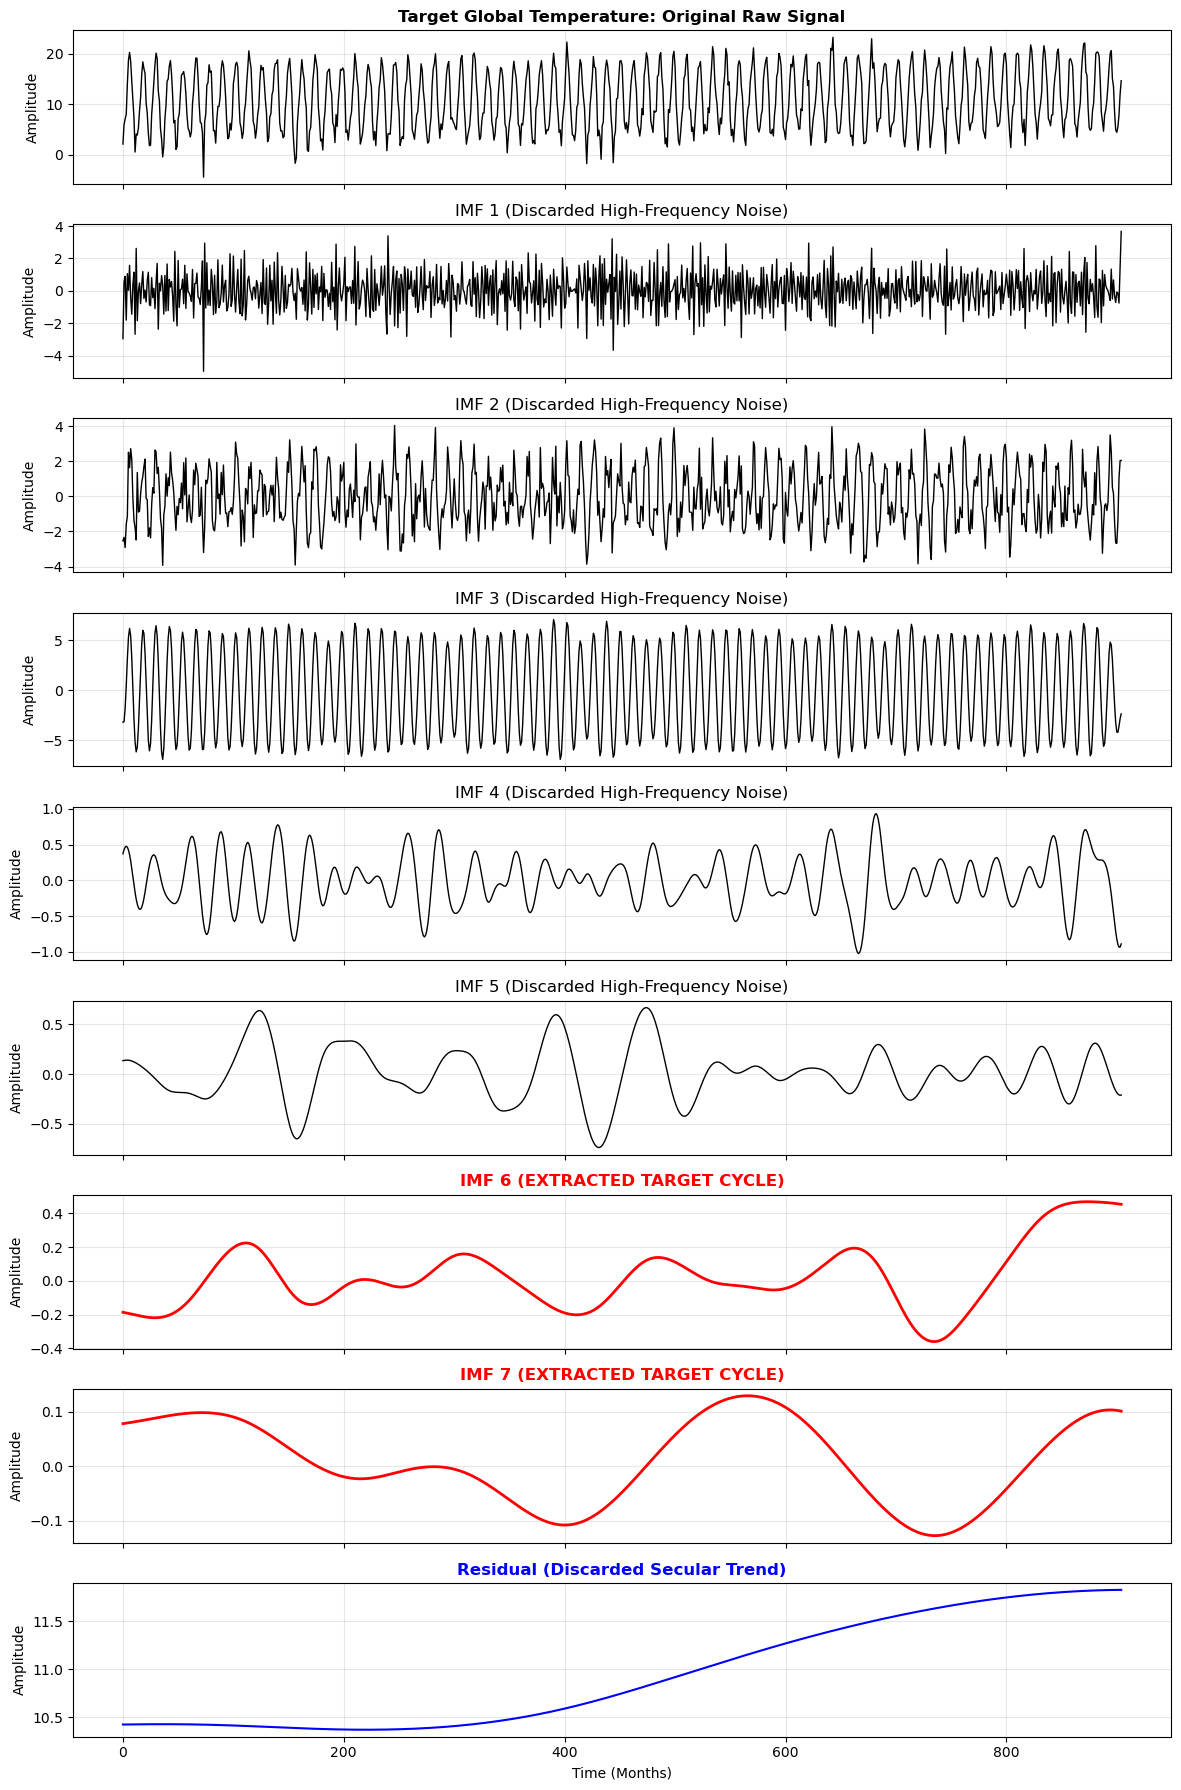

Rendering Spectral Matrix: North Atlantic Oscillation (NAO)
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


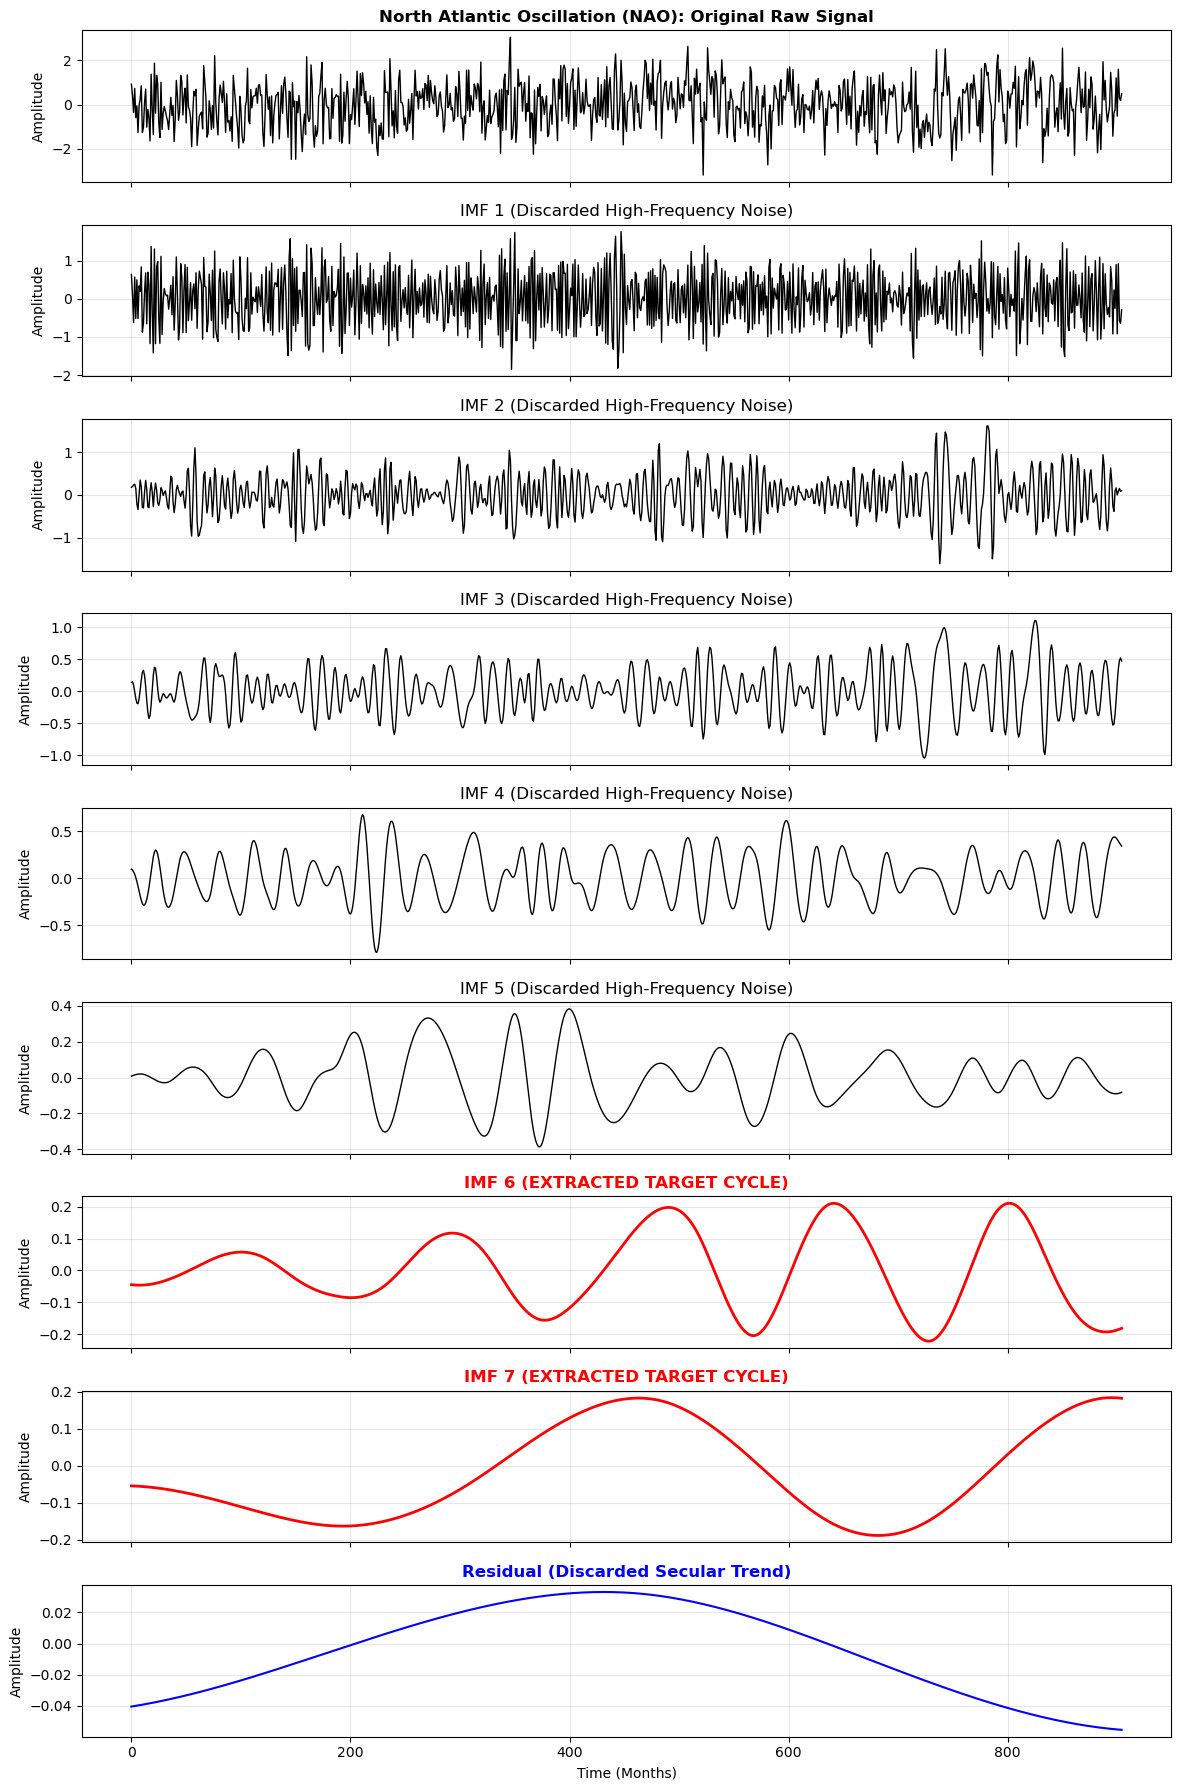

Rendering Spectral Matrix: East Atlantic Pattern (EA)
Mathematical Modes Extracted for Cyclic Tensor: [6]


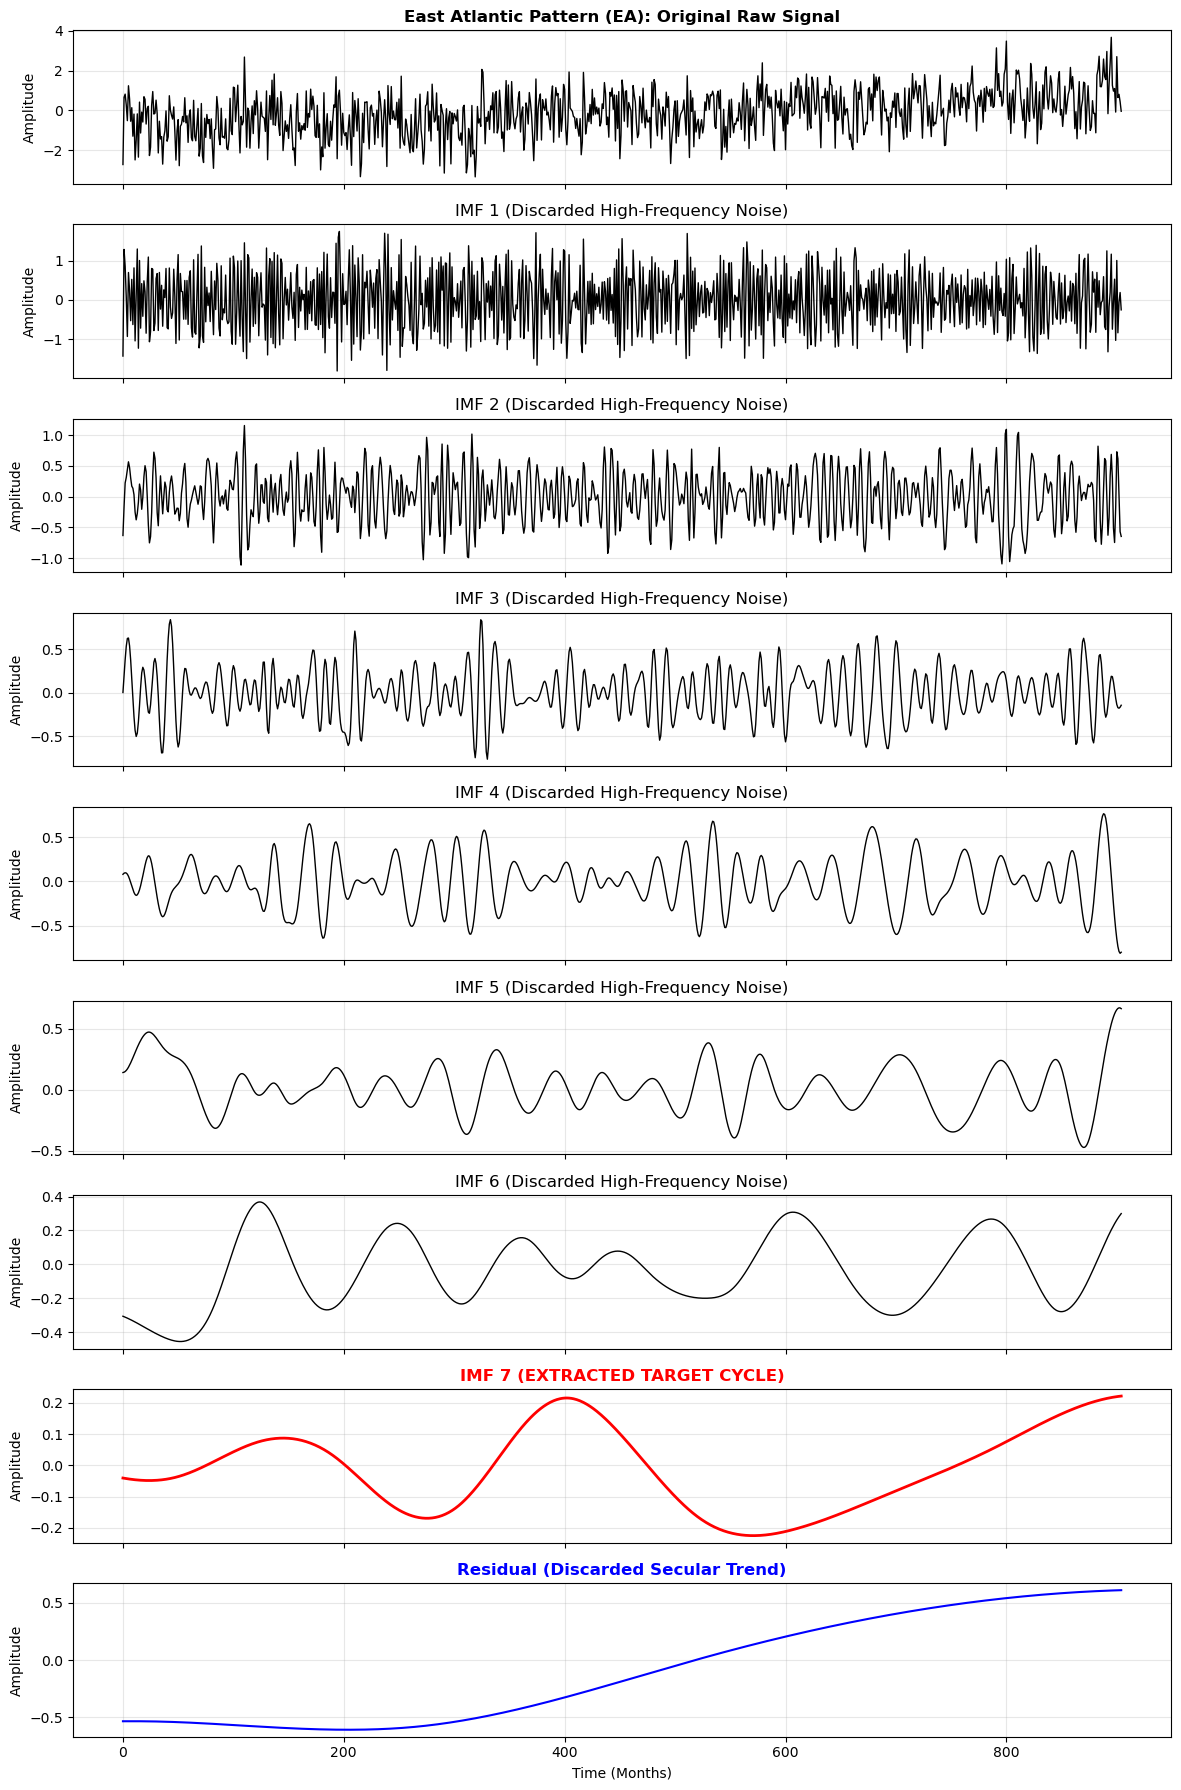

Rendering Spectral Matrix: Scandinavian Blocking (SCA)
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


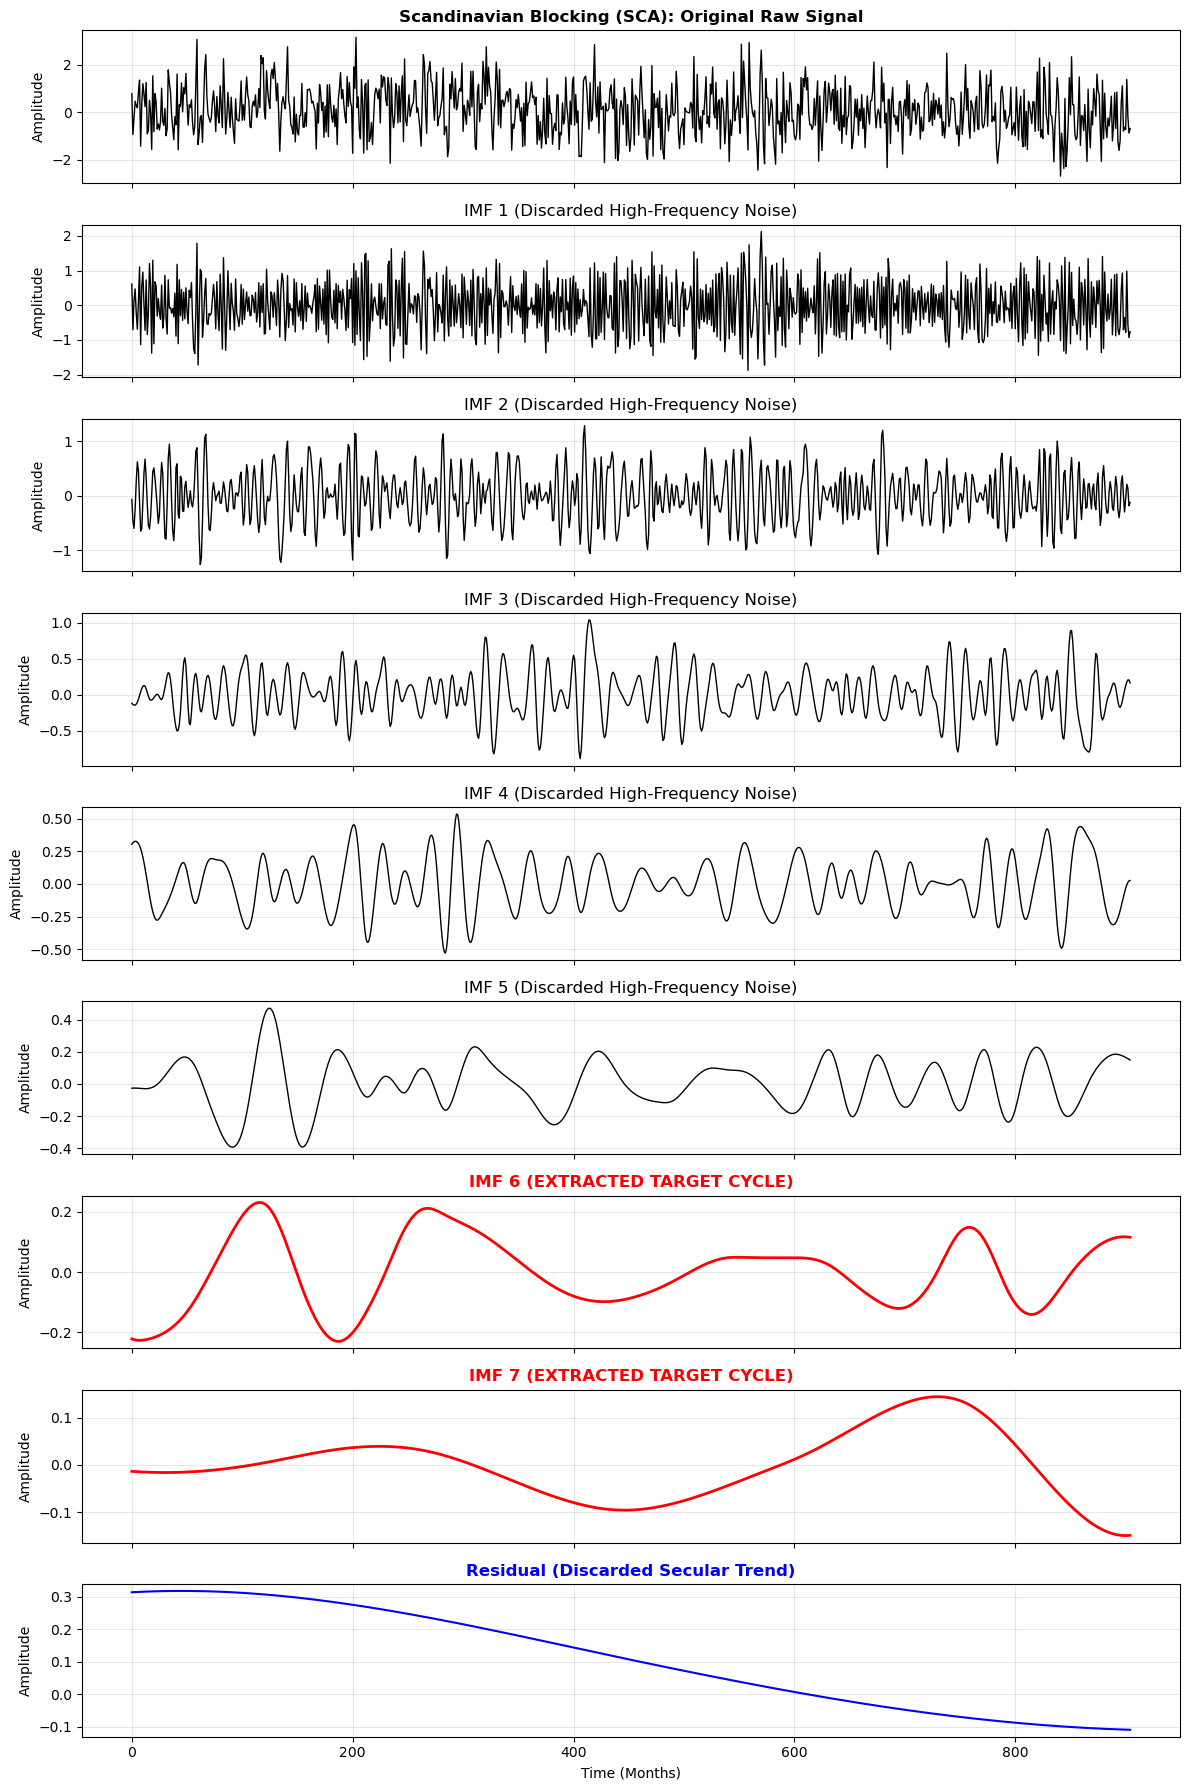

Rendering Spectral Matrix: Atlantic Multidecadal Oscillation (AMO)
Mathematical Modes Extracted for Cyclic Tensor: [5]


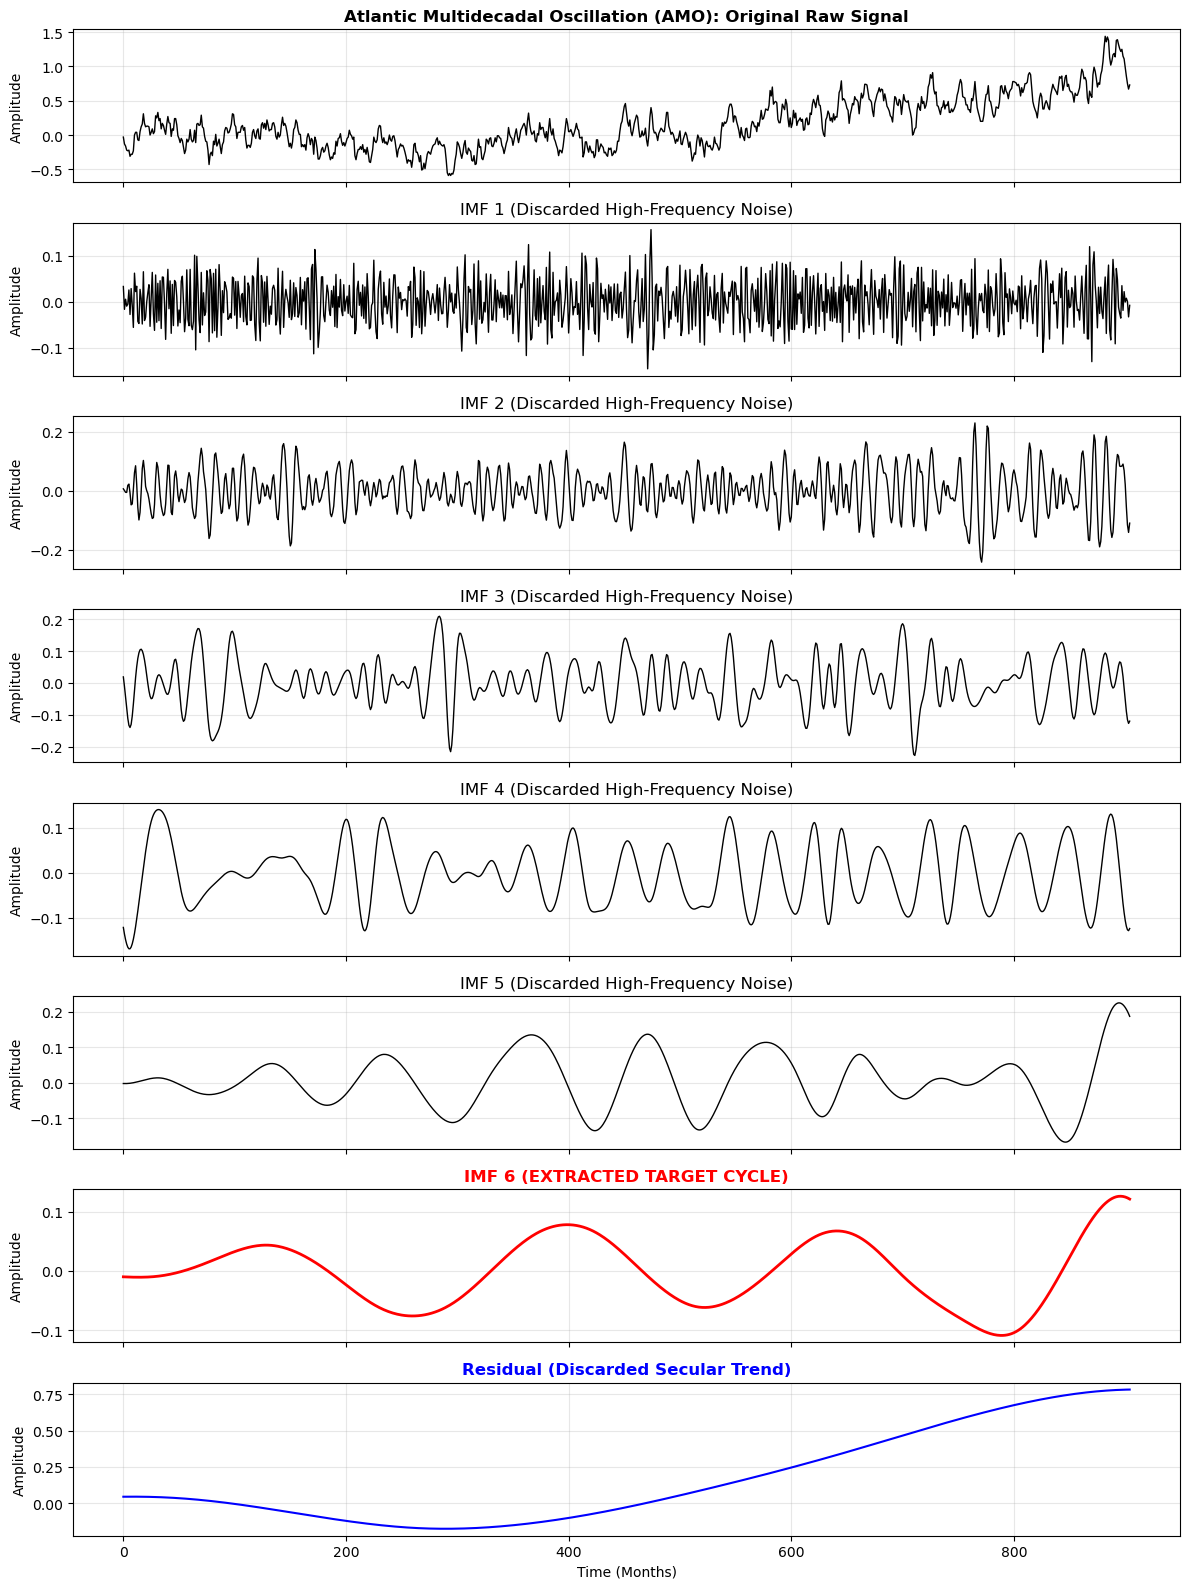

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ceemdan_decomposition(original_series, all_imfs, extracted_indices, title_prefix="Variable"):
    """
    Plots the full CEEMDAN decomposition matrix, highlighting the specific 
    low-frequency IMFs that were extracted to build the cyclic feature matrix.
    
    Parameters:
    original_series (ndarray): The raw 1D input data.
    all_imfs (ndarray): The 2D array output from PyEMD (IMFs + Residual).
    extracted_indices (list): The Python indices (0-based) of the targeted IMFs.
    title_prefix (str): Label for the specific variable being plotted.
    """
    # The last row of the matrix is strictly the residual, not an IMF
    num_imfs = all_imfs.shape[0] - 1 
    time_axis = np.arange(len(original_series))
    
    # Create a dynamic figure height based on the number of extracted modes
    fig, axes = plt.subplots(num_imfs + 2, 1, figsize=(12, 2 * (num_imfs + 2)), sharex=True)
    
    # ==============================================================================
    # 1. Plot the Original Raw Signal
    # ==============================================================================
    axes[0].plot(time_axis, original_series, color='black', linewidth=1)
    axes[0].set_title(f"{title_prefix}: Original Raw Signal", fontweight='bold')
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)
    
    # ==============================================================================
    # 2. Plot the Intrinsic Mode Functions (IMFs)
    # ==============================================================================
    for i in range(num_imfs):
        ax = axes[i + 1]
        
        # Check if this specific IMF is part of your target cyclic reconstruction
        if i in extracted_indices:
            color = 'red'
            linewidth = 2.0
            # Note: Adding 1 to 'i' maps 0-based Python indexing to standard 1-based IMF literature
            title = f"IMF {i + 1} (EXTRACTED TARGET CYCLE)" 
            ax.set_title(title, color=color, fontweight='bold')
        else:
            color = 'black'
            linewidth = 1.0
            title = f"IMF {i + 1} (Discarded High-Frequency Noise)"
            ax.set_title(title)
            
        ax.plot(time_axis, all_imfs[i], color=color, linewidth=linewidth)
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
    
    # ==============================================================================
    # 3. Plot the Non-Stationary Residual
    # ==============================================================================
    axes[-1].plot(time_axis, all_imfs[-1], color='blue', linewidth=1.5)
    axes[-1].set_title("Residual (Discarded Secular Trend)", color='blue', fontweight='bold')
    axes[-1].set_xlabel("Time (Months)")
    axes[-1].set_ylabel("Amplitude")
    axes[-1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# ==============================================================================
# EXECUTION
# ==============================================================================
# Execute this function for each of your preprocessed variables.
# For example, to plot the North Atlantic Oscillation decomposition:
execution_batch = [
    (df_climate['raw'].values, y_all_imfs, y_kept, "Target Global Temperature"),
    (df_climate['NAO'].values, nao_all_imfs, nao_kept, "North Atlantic Oscillation (NAO)"),
    (df_climate['EA'].values, ea_all_imfs, ea_kept, "East Atlantic Pattern (EA)"),
    (df_climate['SCA'].values, sca_all_imfs, sca_kept, "Scandinavian Blocking (SCA)"),
    (df_climate['AMO'].values, amo_all_imfs, amo_kept, "Atlantic Multidecadal Oscillation (AMO)")
]

# Iterate and compute visual matrices
for raw_data, imf_matrix, target_indices, var_name in execution_batch:
    print(f"Rendering Spectral Matrix: {var_name}")
    print(f"Mathematical Modes Extracted for Cyclic Tensor: {target_indices}")
    
    plot_ceemdan_decomposition(
        original_series=raw_data, 
        all_imfs=imf_matrix, 
        extracted_indices=target_indices, 
        title_prefix=var_name
    )

In [20]:
def compute_dynamic_boundaries(imf_metadata):
    """
    Dynamically computes the maximum thermodynamic lag bound for cross-correlation 
    to physically prevent mathematical wave aliasing and phase inversions.
    
    Parameters:
    imf_metadata (dict): A dictionary mapping the variable name to a list of 
                         dominant periods (in months) of its RETAINED IMFs.
                         
    Returns:
    dict: The exact integer bounds to feed into the target_lag_correlation function.
    """
    dynamic_bounds = {}
    
    print("--- COMPUTING DYNAMIC SPECTRAL BOUNDARIES ---")
    for predictor, periods in imf_metadata.items():
        # Ensure only strictly positive numerical periods are evaluated
        valid_periods = [p for p in periods if p > 0 and not np.isinf(p)]
        
        if not valid_periods:
            print(f"Warning: No valid periods for {predictor}. Defaulting to 120.")
            dynamic_bounds[predictor] = 120
            continue
            
        # Extract the fastest macroscopic wave in the retained composite
        p_crit = min(valid_periods)
        
        # Calculate strict cutoff just prior to the λ/2 phase inversion
        max_bound = int(np.floor(p_crit * 0.45))
        
        # Absolute safety overrides (Optional, based on oceanic physics)
        # Prevents micro-boundaries if a high-frequency IMF bypassed the bandpass
        if max_bound < 24: 
            max_bound = 24
            
        dynamic_bounds[predictor] = max_bound
        
        print(f"{predictor}:")
        print(f"  -> Retained Periods: {[round(p, 1) for p in valid_periods]} months")
        print(f"  -> Critical Wave (P_crit): {p_crit:.1f} months")
        print(f"  -> Inversion Threshold (λ/2): {p_crit / 2:.1f} months")
        print(f"  -> ASSIGNED LAG BOUNDARY: {max_bound} months\n")
        
    return dynamic_bounds

# ==============================================================================
# EXECUTION PIPELINE INTEGRATION
# ==============================================================================
# Input the exact dominant periods of the IMFs you retained for each variable.
# (These values are derived directly from the console output of your FFT function).

retained_imf_periods = {    
    'SCA_Cycle': [226.25, 452.50],
    'EA_Cycle': [181.0, 452.5],
    'NAO_Cycle': [181.0, 452.5], 
    'AMO_Cycle': [226.25] 
}

# 1. Compute the strict mathematical limits
calculated_physical_bounds = compute_dynamic_boundaries(retained_imf_periods)


--- COMPUTING DYNAMIC SPECTRAL BOUNDARIES ---
SCA_Cycle:
  -> Retained Periods: [226.2, 452.5] months
  -> Critical Wave (P_crit): 226.2 months
  -> Inversion Threshold (λ/2): 113.1 months
  -> ASSIGNED LAG BOUNDARY: 101 months

EA_Cycle:
  -> Retained Periods: [181.0, 452.5] months
  -> Critical Wave (P_crit): 181.0 months
  -> Inversion Threshold (λ/2): 90.5 months
  -> ASSIGNED LAG BOUNDARY: 81 months

NAO_Cycle:
  -> Retained Periods: [181.0, 452.5] months
  -> Critical Wave (P_crit): 181.0 months
  -> Inversion Threshold (λ/2): 90.5 months
  -> ASSIGNED LAG BOUNDARY: 81 months

AMO_Cycle:
  -> Retained Periods: [226.2] months
  -> Critical Wave (P_crit): 226.2 months
  -> Inversion Threshold (λ/2): 113.1 months
  -> ASSIGNED LAG BOUNDARY: 101 months



Executing Forward Causality Correlation against Temp_Cycle...

--- TARGET MULTIDECADAL LAG SUMMARY ---
Predictor     Target Extraction Window  Peak Correlation (r)  Optimal Lag (Months)                Physical Dynamic
NAO_Cycle Temp_Cycle        1 to 81 mo                0.5722                    28 Macroscopic Thermodynamic Delay
AMO_Cycle Temp_Cycle       1 to 101 mo               -0.5621                    78 Macroscopic Thermodynamic Delay
 EA_Cycle Temp_Cycle        1 to 81 mo                0.2712                    81 Macroscopic Thermodynamic Delay
SCA_Cycle Temp_Cycle       1 to 101 mo               -0.1970                    72 Macroscopic Thermodynamic Delay


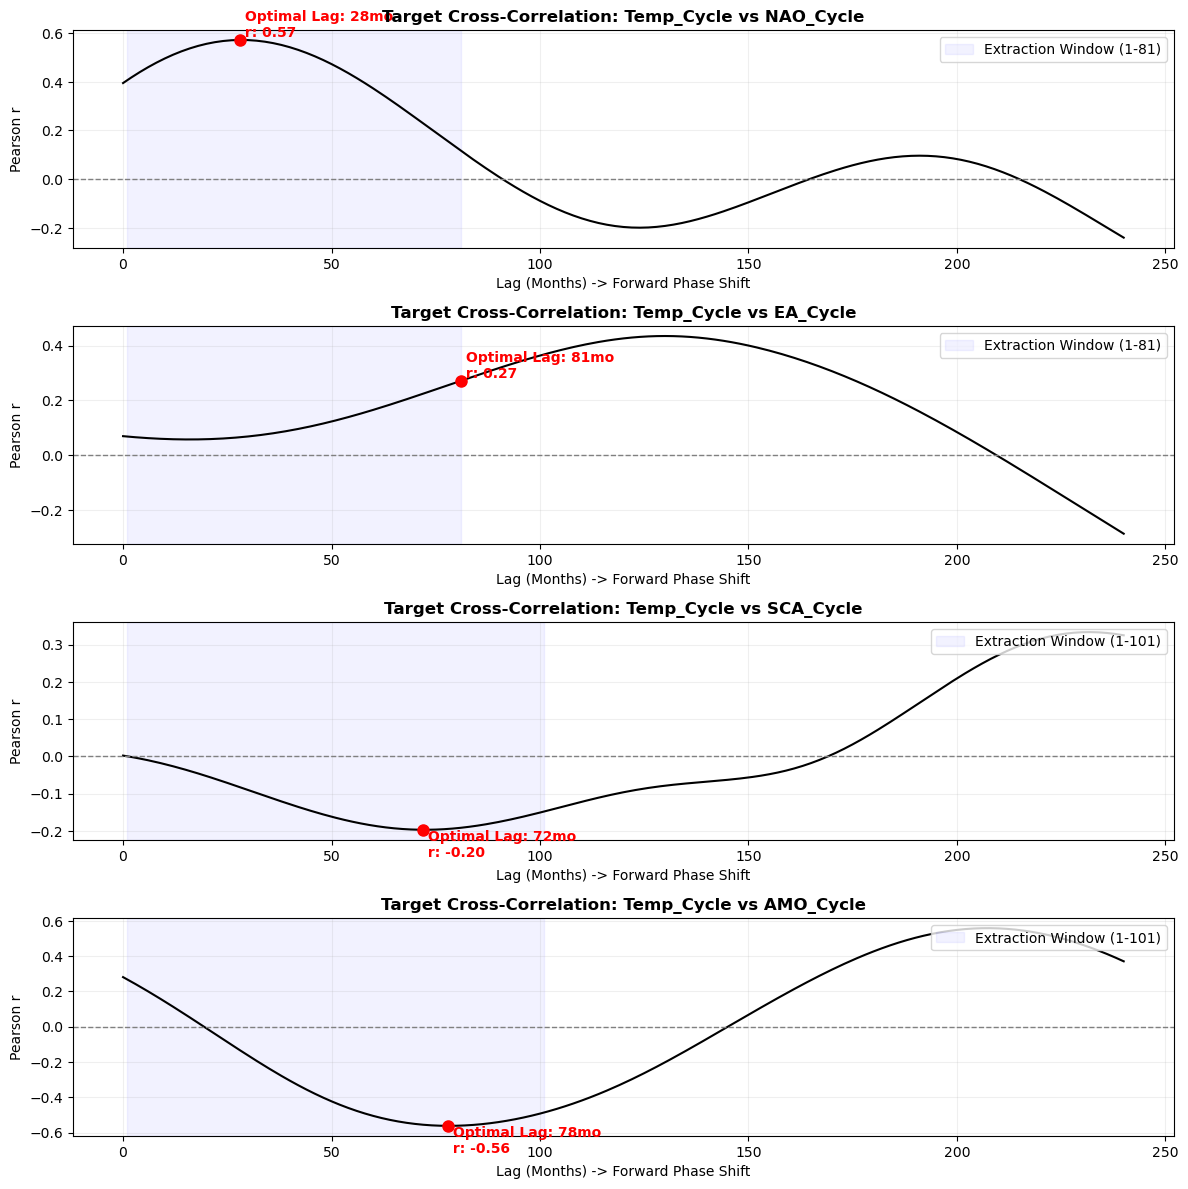

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def target_lag_correlation(df, target_var, predictors, max_lag_plot=240, search_bounds=None):
    if search_bounds is None:
        search_bounds = {p: 120 for p in predictors}

    cross_corr_data = {}
    summary_stats = []
    
    # Base array for all tested lags
    lags = np.arange(0, max_lag_plot + 1)
    
    print(f"Executing Forward Causality Correlation against {target_var}...")
    
    for predictor in predictors:
        correlations = []
        
        for lag in lags:
            shifted_predictor = df[predictor].shift(lag)
            corr = df[target_var].corr(shifted_predictor)
            correlations.append(corr)
            
        correlations = np.array(correlations)
        cross_corr_data[predictor] = correlations
        
        # ==============================================================================
        # MATHEMATICAL EXTRACTION BLOCK
        # ==============================================================================
        upper_bound = search_bounds.get(predictor, 120)
        
        # STRICT BOUNDING: Lag must be > 0 AND <= upper_bound
        valid_indices = np.where((lags <= upper_bound) & (lags > 0))[0]
        valid_lags = lags[valid_indices]
        valid_correlations = correlations[valid_indices]
        
        max_abs_idx = np.argmax(np.abs(valid_correlations))
        peak_corr = valid_correlations[max_abs_idx]
        optimal_lag = valid_lags[max_abs_idx]
            
        summary_stats.append({
            "Predictor": predictor,
            "Target": target_var,
            "Extraction Window": f"1 to {upper_bound} mo",
            "Peak Correlation (r)": round(peak_corr, 4),
            "Optimal Lag (Months)": optimal_lag,
            "Physical Dynamic": "Macroscopic Thermodynamic Delay"
        })
        
    df_summary = pd.DataFrame(summary_stats).sort_values(by="Peak Correlation (r)", key=abs, ascending=False)
    
    return df_summary, cross_corr_data, lags, search_bounds

# ==============================================================================
# EXECUTION
# ==============================================================================
target = 'Temp_Cycle'
# Excluded EA based on previous structural analysis
predictors_to_test = ['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle'] 

physical_bounds = calculated_physical_bounds


df_target_summary, target_corr_data, lag_axis, applied_bounds = target_lag_correlation(
    df=df_gam_filtered, 
    target_var=target, 
    predictors=predictors_to_test, 
    max_lag_plot=240, 
    search_bounds=physical_bounds
)

print("\n--- TARGET MULTIDECADAL LAG SUMMARY ---")
print(df_target_summary.to_string(index=False))

# ==============================================================================
# VISUALIZATION BLOCK
# ==============================================================================
num_plots = len(predictors_to_test)
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3 * num_plots))
if num_plots == 1:
    axes = [axes]

for i, (predictor, corr_array) in enumerate(target_corr_data.items()):
    ax = axes[i]
    ax.plot(lag_axis, corr_array, color='black', linewidth=1.5)
    
    bound_limit = applied_bounds.get(predictor, 120)
    
    # STRICT BOUNDING IN THE PLOT: Synchronized with the math block
    valid_indices = np.where((lag_axis <= bound_limit) & (lag_axis > 0))[0]
    valid_corrs = corr_array[valid_indices]
    
    max_idx = np.argmax(np.abs(valid_corrs))
    peak_lag = lag_axis[valid_indices][max_idx]
    peak_r = valid_corrs[max_idx]
    
    # Baselines and Bounding Area Highlight
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    # Start the blue shading strictly at 1, not 0
    ax.axvspan(1, bound_limit, color='blue', alpha=0.05, label=f'Extraction Window (1-{bound_limit})')
    
    # Highlight Valid Peak
    ax.plot(peak_lag, peak_r, 'ro', markersize=8)
    ax.text(peak_lag, peak_r, f' Optimal Lag: {peak_lag}mo\n r: {peak_r:.2f}', 
             color='red', fontweight='bold', 
             va='bottom' if peak_r > 0 else 'top')
    
    ax.set_title(f"Target Cross-Correlation: {target} vs {predictor}", fontweight='bold')
    ax.set_xlabel("Lag (Months) -> Forward Phase Shift")
    ax.set_ylabel("Pearson r")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
plt.close(fig)

In [123]:
# Apply the transformation
df_gam_filtered['NAO_Cycle'] = (df_gam_filtered['NAO_Cycle'] - np.mean(df_gam_filtered['NAO_Cycle'])) / np.std(df_gam_filtered['NAO_Cycle'])
df_gam_filtered['AMO_Cycle'] = (df_gam_filtered['AMO_Cycle'] - np.mean(df_gam_filtered['AMO_Cycle'])) / np.std(df_gam_filtered['AMO_Cycle'])

In [124]:
df_gam_filtered['AMO_Cycle']

0     -0.135109
1     -0.136116
2     -0.137007
3     -0.137779
4     -0.138425
         ...   
900    2.163488
901    2.163099
902    2.160547
903    2.155872
904    2.149107
Name: AMO_Cycle, Length: 905, dtype: float64

In [125]:
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, 
                                  HuberRegressor, BayesianRidge, OrthogonalMatchingPursuit, Lars)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, l, te

regression_architectures = {

    # =========================================================================
    # CLASS 1: STRICT LINEAR & PENALIZED SKLEARN MODELS (Models 1 - 10)
    # Tests global linear collinearity and autonomous feature selection.
    # =========================================================================
    "01_OLS_All_Features": lambda: make_pipeline(StandardScaler(), LinearRegression()),
    "02_Ridge_Standard_L2": lambda: make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "03_Ridge_Heavy_Penalty": lambda: make_pipeline(StandardScaler(), Ridge(alpha=100.0)),
    "04_Lasso_Strict_Selection": lambda: make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000)),
    "05_Lasso_Micro_Penalty": lambda: make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=10000)),
    "06_ElasticNet_Balanced": lambda: make_pipeline(StandardScaler(), ElasticNet(alpha=0.05, l1_ratio=0.5)),
    "07_Huber_Robust_Outliers": lambda: make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, alpha=0.01, max_iter=2000)),
    "08_Bayesian_Ridge_Probabilistic": lambda: make_pipeline(StandardScaler(), BayesianRidge(max_iter=1000)),
    "09_Orthogonal_Matching_Pursuit": lambda: make_pipeline(StandardScaler(), OrthogonalMatchingPursuit(n_nonzero_coefs=3)),
    "10_Lars_Algorithm": lambda: make_pipeline(StandardScaler(), Lars(n_nonzero_coefs=4)),

    # =========================================================================
    # CLASS 2: ADDITIVE GAMs (NO INTERACTIONS) (Models 11 - 20)
    # Tests non-linear wave distortions without cross-variable modulation.
    # =========================================================================
    "11_GAM_Add_Strict_Linear": lambda: LinearGAM(l(0)+l(1)+l(2)+l(3)+l(4)+l(5)),
    "12_GAM_Add_No_Trend_Linear": lambda: LinearGAM(l(0)+l(1)+l(2)+l(3)), # Isolates Gradient only
    "13_GAM_Add_No_Grad_Linear": lambda: LinearGAM(l(0)+l(1)+l(4)+l(5)), # Isolates Trend only
    "14_GAM_Add_Constrained_Splines": lambda: LinearGAM(
        s(0, n_splines=4, lam=1000) + s(1, n_splines=4, lam=1000) + 
        s(2, n_splines=4, lam=1000) + s(3, n_splines=4, lam=1000) + 
        s(4, n_splines=4, lam=1000) + s(5, n_splines=4, lam=1000)
    ),
    "15_GAM_Add_Cyclic_Spline_Linear_Secular": lambda: LinearGAM(
        s(0, n_splines=4) + s(1, n_splines=4) + l(2) + l(3) + l(4) + l(5)
    ),
    "16_GAM_Add_AMO_Dominance": lambda: LinearGAM(s(1, n_splines=6) + l(3) + l(5)), # AMO only
    "17_GAM_Add_NAO_Dominance": lambda: LinearGAM(s(0, n_splines=6) + l(2) + l(4)), # NAO only
    "18_GAM_Add_Order1_Splines": lambda: LinearGAM(
        s(0, spline_order=1, n_splines=2) + s(1, spline_order=1, n_splines=2) +
        s(2, spline_order=1, n_splines=2) + s(3, spline_order=1, n_splines=2) +
        s(4, spline_order=1, n_splines=2) + s(5, spline_order=1, n_splines=2)
    ),
    "19_GAM_Add_Flex_Spline_High_Penalty": lambda: LinearGAM(
        s(0, n_splines=8, lam=5000) + s(1, n_splines=8, lam=5000) + l(4) + l(5)
    ),
    "20_GAM_Add_Ocean_Gradient_Only": lambda: LinearGAM(s(1, n_splines=4) + s(3, n_splines=4)),

    # =========================================================================
    # CLASS 3: VARYING COEFFICIENTS (GRADIENT MODULATED) (Models 21 - 30)
    # Tests if the *velocity* of warming amplifies/dampens oceanic forcing.
    # =========================================================================
    "21_GAM_VC_Grad_NAO_Only": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=2)),
    "22_GAM_VC_Grad_AMO_Only": lambda: LinearGAM(s(1, by=3, spline_order=1, n_splines=2)),
    "23_GAM_VC_Grad_Synchronized": lambda: LinearGAM(
        s(0, by=2, spline_order=1, n_splines=2) + 
        s(1, by=3, spline_order=1, n_splines=2)
    ),
    "24_GAM_VC_Grad_Sync_Plus_Linear_Trend": lambda: LinearGAM(
        s(0, by=2, spline_order=1, n_splines=2) + 
        s(1, by=3, spline_order=1, n_splines=2) + l(4) + l(5)
    ),
    "25_GAM_VC_Grad_Cross_Modulation": lambda: LinearGAM(
        s(0, by=3, spline_order=1, n_splines=2) + # NAO modulated by AMO's Gradient
        s(1, by=2, spline_order=1, n_splines=2)   # AMO modulated by NAO's Gradient
    ),
    "26_GAM_VC_Grad_Cubic_Splines": lambda: LinearGAM(
        s(0, by=2, n_splines=4, lam=100) + s(1, by=3, n_splines=4, lam=100)
    ),
    "27_GAM_VC_Grad_Base_Plus_Modulation": lambda: LinearGAM(
        l(0) + l(1) + s(0, by=2, spline_order=1, n_splines=2) + s(1, by=3, spline_order=1, n_splines=2)
    ),
    "28_GAM_VC_Grad_AMO_Dominant_Sync": lambda: LinearGAM(
        l(0) + s(1, by=3, spline_order=1, n_splines=2)
    ),
    "29_GAM_VC_Grad_NAO_Dominant_Sync": lambda: LinearGAM(
        s(0, by=2, spline_order=1, n_splines=2) + l(1)
    ),
    "30_GAM_VC_Grad_Heavy_Smoothing": lambda: LinearGAM(
        s(0, by=2, spline_order=1, n_splines=2, lam=5000) + 
        s(1, by=3, spline_order=1, n_splines=2, lam=5000)
    ),

    # =========================================================================
    # CLASS 4: VARYING COEFFICIENTS (TREND MODULATED) (Models 31 - 40)
    # Tests if the *absolute baseline temperature* alters oceanic forcing.
    # Will likely demonstrate negative R2 extrapolation failures.
    # =========================================================================
    "31_GAM_VC_Trend_NAO_Only": lambda: LinearGAM(s(0, by=4, spline_order=1, n_splines=2)),
    "32_GAM_VC_Trend_AMO_Only": lambda: LinearGAM(s(1, by=5, spline_order=1, n_splines=2)),
    "33_GAM_VC_Trend_Synchronized": lambda: LinearGAM(
        s(0, by=4, spline_order=1, n_splines=2) + 
        s(1, by=5, spline_order=1, n_splines=2)
    ),
    "34_GAM_VC_Trend_Sync_Plus_Linear_Grad": lambda: LinearGAM(
        s(0, by=4, spline_order=1, n_splines=2) + 
        s(1, by=5, spline_order=1, n_splines=2) + l(2) + l(3)
    ),
    "35_GAM_VC_Trend_Cross_Modulation": lambda: LinearGAM(
        s(0, by=5, spline_order=1, n_splines=2) + 
        s(1, by=4, spline_order=1, n_splines=2)
    ),
    "36_GAM_VC_Trend_Cubic_Splines": lambda: LinearGAM(
        s(0, by=4, n_splines=4, lam=100) + s(1, by=5, n_splines=4, lam=100)
    ),
    "37_GAM_VC_Trend_Base_Plus_Modulation": lambda: LinearGAM(
        l(0) + l(1) + s(0, by=4, spline_order=1, n_splines=2) + s(1, by=5, spline_order=1, n_splines=2)
    ),
    "38_GAM_VC_Dual_Sync_Modulation": lambda: LinearGAM(
        s(0, by=2, spline_order=1, n_splines=2) + # NAO by Grad
        s(0, by=4, spline_order=1, n_splines=2) + # NAO by Trend
        s(1, by=3, spline_order=1, n_splines=2) + # AMO by Grad
        s(1, by=5, spline_order=1, n_splines=2)   # AMO by Trend
    ),
    "39_GAM_VC_Trend_AMO_Dominant_Sync": lambda: LinearGAM(l(0) + s(1, by=5, spline_order=1, n_splines=2)),
    "40_GAM_VC_Trend_Heavy_Smoothing": lambda: LinearGAM(
        s(0, by=4, spline_order=1, n_splines=2, lam=5000) + 
        s(1, by=5, spline_order=1, n_splines=2, lam=5000)
    ),

    # =========================================================================
    # CLASS 5: TENSOR PLANES & CROSS-SPECTRAL INTERFERENCE (Models 41 - 50)
    # Computes 3D interaction surfaces between variables.
    # =========================================================================
    "41_GAM_TE_AMO_Grad_Bilinear": lambda: LinearGAM(te(1, 3, spline_order=1, n_splines=[2, 2])),
    "42_GAM_TE_NAO_Grad_Bilinear": lambda: LinearGAM(te(0, 2, spline_order=1, n_splines=[2, 2])),
    "43_GAM_TE_Grad_Sync_Bilinear": lambda: LinearGAM(
        te(0, 2, spline_order=1, n_splines=[2, 2]) + 
        te(1, 3, spline_order=1, n_splines=[2, 2])
    ),
    "44_GAM_TE_Trend_Sync_Bilinear": lambda: LinearGAM(
        te(0, 4, spline_order=1, n_splines=[2, 2]) + 
        te(1, 5, spline_order=1, n_splines=[2, 2])
    ),
    "45_GAM_TE_Oceanic_Interference": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 2])),
    "46_GAM_TE_Oceanic_Plus_Linear_Secular": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(2) + l(3) + l(4) + l(5)
    ),
    "47_GAM_TE_Gradient_Interference": lambda: LinearGAM(
        te(2, 3, spline_order=1, n_splines=[2, 2]) # Interaction of the two velocities
    ),
    "48_GAM_TE_Dual_Interference_Planes": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + # Oceanic interference
        te(2, 3, spline_order=1, n_splines=[2, 2])   # Gradient interference
    ),
    "48bis_GAM_TE_Dual_Interference_Planes": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[3, 3]) + # Oceanic interference
        te(2, 3, spline_order=2, n_splines=[3, 3])   # Gradient interference
    ),
    "49_GAM_TE_Complex_Quadratic_Planes": lambda: LinearGAM(
        te(0, 2, spline_order=2, n_splines=[3, 3], lam=500) + 
        te(1, 3, spline_order=2, n_splines=[3, 3], lam=500)
    ),
    "50_GAM_TE_Absolute_Architecture": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + # Phase coupling
        te(1, 3, spline_order=1, n_splines=[2, 2]) + # AMO Modulated by Grad
        l(5)                                         # Additive Trend Base
    ),
    "51_GAM_Pure_Oceanic_Linear": lambda: LinearGAM(l(0) + l(1)),
    "52_GAM_Pure_Oceanic_Order1_Splines": lambda: LinearGAM(
        s(0, spline_order=1, n_splines=2) + s(1, spline_order=1, n_splines=2)
    ),
    "53_GAM_Pure_Oceanic_Constrained_Splines": lambda: LinearGAM(
        s(0, n_splines=4, lam=1000) + s(1, n_splines=4, lam=1000)
    ),
    
    # 2. Single-Feature Baselines (To verify independent causal power)
    "54_GAM_Pure_Oceanic_AMO_Only_Linear": lambda: LinearGAM(l(1)),
    "55_GAM_Pure_Oceanic_NAO_Only_Linear": lambda: LinearGAM(l(0)),
    
    # 3. Pure Internal Cross-Spectral Interference (Tensor Planes)
    # Tests if the NAO and AMO interact physically with each other, 
    # independent of background warming.
    "56_GAM_Pure_Oceanic_Tensor_Bilinear": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2])
    ),
    "57_GAM_Pure_Oceanic_Tensor_Cubic": lambda: LinearGAM(
        te(0, 1, n_splines=[4, 4], lam=1000)
    ),
    
    # 4. Pure Internal Varying Coefficients
    # Tests directional modulation (e.g., does a high AMO amplify the NAO's impact?)
    "58_GAM_Pure_Oceanic_VC_AMO_Modulating_NAO": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2)
    ),
    "59_GAM_Pure_Oceanic_VC_NAO_Modulating_AMO": lambda: LinearGAM(
        s(1, by=0, spline_order=1, n_splines=2)
    ),
    "60_GAM_Pure_Oceanic_VC_Full_Cross_Modulation": lambda: LinearGAM(
        l(0) + l(1) + 
        s(0, by=1, spline_order=1, n_splines=2) + 
        s(1, by=0, spline_order=1, n_splines=2)
    ),
    # =========================================================================
    # CLASS 7: CONTEMPORANEOUS TREND FORCING (Models 61 - 100)
    # Evaluates the direct additive and modulating effects of the actual, 
    # unshifted secular trend present at the time of climatic impact.
    # =========================================================================

    # -------------------------------------------------------------------------
    # Subclass 7A: Strict Additive Contemporaneous Baseline (61 - 70)
    # Tests if the current trend operates entirely independently of the cycles.
    # -------------------------------------------------------------------------
    "61_GAM_Contemp_Trend_Only_Linear": lambda: LinearGAM(l(6)),
    "62_GAM_Contemp_Trend_Only_Spline": lambda: LinearGAM(s(6, n_splines=4, lam=1000)),
    "63_GAM_Add_Cycles_Plus_Contemp_Linear": lambda: LinearGAM(l(0) + l(1) + l(6)),
    "64_GAM_Add_Cycles_Plus_Contemp_Order1": lambda: LinearGAM(
        s(0, spline_order=1, n_splines=2) + s(1, spline_order=1, n_splines=2) + l(6)
    ),
    "65_GAM_Add_Cycles_Plus_Contemp_Constrained": lambda: LinearGAM(
        s(0, n_splines=4, lam=1000) + s(1, n_splines=4, lam=1000) + s(6, n_splines=4, lam=1000)
    ),
    "66_GAM_Add_AMO_Plus_Contemp_Linear": lambda: LinearGAM(l(1) + l(6)),
    "67_GAM_Add_NAO_Plus_Contemp_Linear": lambda: LinearGAM(l(0) + l(6)),
    "68_GAM_Add_All_Trends_Linear": lambda: LinearGAM(l(4) + l(5) + l(6)),
    "69_GAM_Add_Current_Trend_Plus_Historic_Grad": lambda: LinearGAM(l(0) + l(1) + l(2) + l(3) + l(6)),
    "70_GAM_Add_Full_Matrix_Linear": lambda: LinearGAM(l(0)+l(1)+l(2)+l(3)+l(4)+l(5)+l(6)),

    # -------------------------------------------------------------------------
    # Subclass 7B: Contemporaneous Varying Coefficients (71 - 80)
    # Tests if the baseline temperature today physically alters the amplitude 
    # of the oceanic wave arriving today (Sensible heat flux modulation).
    # -------------------------------------------------------------------------
    "71_GAM_VC_Contemp_Modulating_NAO": lambda: LinearGAM(s(0, by=6, spline_order=1, n_splines=2)),
    "72_GAM_VC_Contemp_Modulating_AMO": lambda: LinearGAM(s(1, by=6, spline_order=1, n_splines=2)),
    "73_GAM_VC_Contemp_Modulating_Both": lambda: LinearGAM(
        s(0, by=6, spline_order=1, n_splines=2) + 
        s(1, by=6, spline_order=1, n_splines=2)
    ),
    "74_GAM_VC_Contemp_Mod_Both_Plus_Linear_Base": lambda: LinearGAM(
        l(0) + l(1) + 
        s(0, by=6, spline_order=1, n_splines=2) + 
        s(1, by=6, spline_order=1, n_splines=2)
    ),
    "75_GAM_VC_Contemp_Mod_Both_Plus_Contemp_Base": lambda: LinearGAM(
        l(6) + 
        s(0, by=6, spline_order=1, n_splines=2) + 
        s(1, by=6, spline_order=1, n_splines=2)
    ),
    "76_GAM_VC_Contemp_AMO_Dominant": lambda: LinearGAM(l(0) + l(6) + s(1, by=6, spline_order=1, n_splines=2)),
    "77_GAM_VC_Contemp_NAO_Dominant": lambda: LinearGAM(l(1) + l(6) + s(0, by=6, spline_order=1, n_splines=2)),
    "78_GAM_VC_Contemp_Cubic_Splines": lambda: LinearGAM(
        s(0, by=6, n_splines=4, lam=1000) + s(1, by=6, n_splines=4, lam=1000)
    ),
    "79_GAM_VC_Dual_Epoch_Modulation_AMO": lambda: LinearGAM(
        s(1, by=5, spline_order=1, n_splines=2) + # Modulated by historic trend
        s(1, by=6, spline_order=1, n_splines=2)   # Modulated by current trend
    ),
    "80_GAM_VC_Dual_Epoch_Modulation_NAO": lambda: LinearGAM(
        s(0, by=4, spline_order=1, n_splines=2) + 
        s(0, by=6, spline_order=1, n_splines=2)
    ),

    # -------------------------------------------------------------------------
    # Subclass 7C: Contemporaneous Tensor Planes (81 - 90)
    # Computes restricted 3D geometric surfaces between the incoming oceanic 
    # anomalies and the current atmospheric boundary state.
    # -------------------------------------------------------------------------
    "81_GAM_TE_Contemp_NAO_Bilinear": lambda: LinearGAM(te(0, 6, spline_order=1, n_splines=[2, 2])),
    "82_GAM_TE_Contemp_AMO_Bilinear": lambda: LinearGAM(te(1, 6, spline_order=1, n_splines=[2, 2])),
    "83_GAM_TE_Contemp_Dual_Bilinear": lambda: LinearGAM(
        te(0, 6, spline_order=1, n_splines=[2, 2]) + 
        te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "84_GAM_TE_Contemp_Dual_Plus_Linear_Bases": lambda: LinearGAM(
        l(0) + l(1) + l(6) + 
        te(0, 6, spline_order=1, n_splines=[2, 2]) + 
        te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "85_GAM_TE_Contemp_Trend_Interaction": lambda: LinearGAM(
        te(4, 6, spline_order=1, n_splines=[2, 2]) + # Historic NAO trend vs Current Trend
        te(5, 6, spline_order=1, n_splines=[2, 2])   # Historic AMO trend vs Current Trend
    ),
    "86_GAM_TE_Contemp_Gradient_Interaction": lambda: LinearGAM(
        te(2, 6, spline_order=1, n_splines=[2, 2]) + 
        te(3, 6, spline_order=1, n_splines=[2, 2])
    ),
    "87_GAM_TE_Contemp_Quadratic_Constrained": lambda: LinearGAM(
        te(0, 6, spline_order=2, n_splines=[3, 3], lam=5000) + 
        te(1, 6, spline_order=2, n_splines=[3, 3], lam=5000)
    ),
    "88_GAM_TE_Internal_Oceanic_Plus_Contemp_Base": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(6)
    ),
    "89_GAM_TE_Full_Bilinear_Network": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(0, 6, spline_order=1, n_splines=[2, 2]) + 
        te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "90_GAM_TE_AMO_Contemp_Plane_Only": lambda: LinearGAM(
        te(1, 6, spline_order=1, n_splines=[2, 2]) + l(0)
    ),

    # -------------------------------------------------------------------------
    # Subclass 7D: Cross-Epoch Interferences (91 - 100)
    # Mathematically isolates whether the historical baseline (integration time) 
    # or the current baseline (arrival time) governs the thermodynamic equation.
    # -------------------------------------------------------------------------
    "91_GAM_Cross_Epoch_AMO_VC_Competition": lambda: LinearGAM(
        s(1, by=5, spline_order=1, n_splines=2) + s(1, by=6, spline_order=1, n_splines=2) + l(1)
    ),
    "92_GAM_Cross_Epoch_NAO_VC_Competition": lambda: LinearGAM(
        s(0, by=4, spline_order=1, n_splines=2) + s(0, by=6, spline_order=1, n_splines=2) + l(0)
    ),
    "93_GAM_Cross_Epoch_TE_Competition": lambda: LinearGAM(
        te(1, 5, spline_order=1, n_splines=[2, 2]) + 
        te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "94_GAM_Cross_Epoch_Additive_Linear": lambda: LinearGAM(l(0) + l(1) + l(4) + l(5) + l(6)),
    "95_GAM_Cross_Epoch_Grad_Current_Competition": lambda: LinearGAM(
        s(1, by=3, spline_order=1, n_splines=2) + # AMO by Historic Gradient
        s(1, by=6, spline_order=1, n_splines=2)   # AMO by Current Absolute Trend
    ),
    "96_GAM_Cross_Epoch_NAO_Grad_Current_Competition": lambda: LinearGAM(
        s(0, by=2, spline_order=1, n_splines=2) + 
        s(0, by=6, spline_order=1, n_splines=2)
    ),
    "97_GAM_VC_Contemp_Modulating_Historic_Trend": lambda: LinearGAM(
        s(4, by=6, spline_order=1, n_splines=2) + 
        s(5, by=6, spline_order=1, n_splines=2)
    ),
    "98_GAM_TE_Full_Epoch_Bilinear": lambda: LinearGAM(
        te(0, 4, spline_order=1, n_splines=[2, 2]) + te(0, 6, spline_order=1, n_splines=[2, 2]) +
        te(1, 5, spline_order=1, n_splines=[2, 2]) + te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "99_GAM_Add_All_Univariate_Splines": lambda: LinearGAM(
        s(0, n_splines=4, lam=1000) + s(1, n_splines=4, lam=1000) + 
        s(4, n_splines=4, lam=1000) + s(5, n_splines=4, lam=1000) + s(6, n_splines=4, lam=1000)
    ),
    "100_GAM_Absolute_Contemp_Supremacy": lambda: LinearGAM(
        s(6, by=0, spline_order=1, n_splines=2) + s(6, by=1, spline_order=1, n_splines=2) + l(6)
    ),
    # =========================================================================
    # CLASS 8: TRI-STATE TREND MODULATION WITH INTERNAL INTERFERENCE (101 - 140)
    # Tests combinations where the AMO and NAO interact with each other while 
    # simultaneously being subjected to the 3 different baseline physics.
    # =========================================================================

    # -------------------------------------------------------------------------
    # Subclass 8A: Oceanic Tensor Plane + Additive Tri-State Trends (101 - 105)
    # Allows NAO and AMO to interact, but forces the background states to remain additive.
    # -------------------------------------------------------------------------
    "101_GAM_TE_Ocean_Plus_Add_Grad": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(2) + l(3)
    ),
    "102_GAM_TE_Ocean_Plus_Add_Historic": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(4) + l(5)
    ),
    "103_GAM_TE_Ocean_Plus_Add_Contemp": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(6)
    ),
    "104_GAM_TE_Ocean_Plus_Add_Grad_Contemp": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(2) + l(3) + l(6)
    ),
    "105_GAM_TE_Ocean_Plus_Add_All_States": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(2) + l(3) + l(4) + l(5) + l(6)
    ),

    # -------------------------------------------------------------------------
    # Subclass 8B: Oceanic Tensor Plane + Varying Coefficient Trends (106 - 115)
    # NAO and AMO interact physically, and their individual amplitudes are 
    # simultaneously modulated by the specific background states.
    # -------------------------------------------------------------------------
    "106_GAM_TE_Ocean_VC_Grad_Modulation": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(0, by=2, spline_order=1, n_splines=2) + s(1, by=3, spline_order=1, n_splines=2)
    ),
    "107_GAM_TE_Ocean_VC_Historic_Modulation": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(0, by=4, spline_order=1, n_splines=2) + s(1, by=5, spline_order=1, n_splines=2)
    ),
    "108_GAM_TE_Ocean_VC_Contemp_Modulation": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(0, by=6, spline_order=1, n_splines=2) + s(1, by=6, spline_order=1, n_splines=2)
    ),
    "109_GAM_TE_Ocean_VC_Grad_Plus_Contemp": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(0, by=2, spline_order=1, n_splines=2) + s(1, by=3, spline_order=1, n_splines=2) + 
        s(0, by=6, spline_order=1, n_splines=2) + s(1, by=6, spline_order=1, n_splines=2)
    ),
    "110_GAM_TE_Ocean_VC_AMO_Grad_NAO_Contemp": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(1, by=3, spline_order=1, n_splines=2) + # AMO by Historic Grad
        s(0, by=6, spline_order=1, n_splines=2)   # NAO by Contemp Baseline
    ),
    "111_GAM_TE_Ocean_VC_NAO_Grad_AMO_Contemp": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(0, by=2, spline_order=1, n_splines=2) + 
        s(1, by=6, spline_order=1, n_splines=2)
    ),
    "112_GAM_TE_Ocean_VC_Historic_Plus_Contemp_AMO": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(1, by=5, spline_order=1, n_splines=2) + s(1, by=6, spline_order=1, n_splines=2)
    ),
    "113_GAM_TE_Ocean_VC_Historic_Plus_Contemp_NAO": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(0, by=4, spline_order=1, n_splines=2) + s(0, by=6, spline_order=1, n_splines=2)
    ),
    "114_GAM_TE_Ocean_VC_Tri_State_AMO_Only": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(0) +
        s(1, by=3, spline_order=1, n_splines=2) + 
        s(1, by=5, spline_order=1, n_splines=2) + 
        s(1, by=6, spline_order=1, n_splines=2)
    ),
    "115_GAM_TE_Ocean_VC_Tri_State_NAO_Only": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + l(1) +
        s(0, by=2, spline_order=1, n_splines=2) + 
        s(0, by=4, spline_order=1, n_splines=2) + 
        s(0, by=6, spline_order=1, n_splines=2)
    ),

    # -------------------------------------------------------------------------
    # Subclass 8C: Asymmetric Oceanic VC + Tri-State Modulations (116 - 125)
    # Computes directional oceanic forcing (e.g., AMO amplifying NAO) combined 
    # with the background trend scalars.
    # -------------------------------------------------------------------------
    "116_GAM_VC_AMO_Mods_NAO_Plus_Grad": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + l(2) + l(3)
    ),
    "117_GAM_VC_NAO_Mods_AMO_Plus_Grad": lambda: LinearGAM(
        s(1, by=0, spline_order=1, n_splines=2) + l(2) + l(3)
    ),
    "118_GAM_VC_AMO_Mods_NAO_Plus_Contemp": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + l(6)
    ),
    "119_GAM_VC_Cross_Ocean_Plus_Contemp_VC": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + # AMO mods NAO
        s(0, by=6, spline_order=1, n_splines=2) + # Contemp mods NAO
        s(1, by=6, spline_order=1, n_splines=2)   # Contemp mods AMO
    ),
    "120_GAM_VC_Cross_Ocean_Plus_Grad_VC": lambda: LinearGAM(
        s(1, by=0, spline_order=1, n_splines=2) + # NAO mods AMO
        s(0, by=2, spline_order=1, n_splines=2) + # Grad mods NAO
        s(1, by=3, spline_order=1, n_splines=2)   # Grad mods AMO
    ),
    "121_GAM_VC_Cross_Ocean_Dual_Epoch_AMO": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + 
        s(1, by=5, spline_order=1, n_splines=2) + s(1, by=6, spline_order=1, n_splines=2)
    ),
    "122_GAM_VC_Cross_Ocean_Dual_Epoch_NAO": lambda: LinearGAM(
        s(1, by=0, spline_order=1, n_splines=2) + 
        s(0, by=4, spline_order=1, n_splines=2) + s(0, by=6, spline_order=1, n_splines=2)
    ),
    "123_GAM_VC_Cross_Ocean_Grad_Contemp_Compete": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + 
        s(1, by=3, spline_order=1, n_splines=2) + s(0, by=6, spline_order=1, n_splines=2)
    ),
    "124_GAM_VC_Full_Ocean_Cross_Plus_Grad": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + s(1, by=0, spline_order=1, n_splines=2) + 
        s(0, by=2, spline_order=1, n_splines=2) + s(1, by=3, spline_order=1, n_splines=2)
    ),
    "125_GAM_VC_Full_Ocean_Cross_Plus_Contemp": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + s(1, by=0, spline_order=1, n_splines=2) + 
        s(0, by=6, spline_order=1, n_splines=2) + s(1, by=6, spline_order=1, n_splines=2)
    ),

    # -------------------------------------------------------------------------
    # Subclass 8D: Multi-Plane Tensors (126 - 140)
    # Computes fully interacting continuous surfaces. Extremely high risk of 
    # extrapolation failure if the true physics are strictly additive.
    # -------------------------------------------------------------------------
    "126_GAM_TE_Multi_Plane_Ocean_Grad": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(0, 2, spline_order=1, n_splines=[2, 2]) + 
        te(1, 3, spline_order=1, n_splines=[2, 2])
    ),
    "127_GAM_TE_Multi_Plane_Ocean_Contemp": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(0, 6, spline_order=1, n_splines=[2, 2]) + 
        te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "128_GAM_TE_Multi_Plane_Ocean_Historic": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(0, 4, spline_order=1, n_splines=[2, 2]) + 
        te(1, 5, spline_order=1, n_splines=[2, 2])
    ),
    "129_GAM_TE_Dual_Epoch_Plane_AMO": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(1, 5, spline_order=1, n_splines=[2, 2]) + 
        te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "130_GAM_TE_Dual_Epoch_Plane_NAO": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(0, 4, spline_order=1, n_splines=[2, 2]) + 
        te(0, 6, spline_order=1, n_splines=[2, 2])
    ),
    "131_GAM_TE_Ocean_Plus_All_Trend_Planes": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(2, 6, spline_order=1, n_splines=[2, 2]) + # Grad vs Contemp
        te(3, 6, spline_order=1, n_splines=[2, 2])
    ),
    "132_GAM_TE_Ocean_Plus_Historic_vs_Contemp": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(4, 6, spline_order=1, n_splines=[2, 2]) + 
        te(5, 6, spline_order=1, n_splines=[2, 2])
    ),
    "133_GAM_TE_AMO_Dominant_Multi_Plane": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(1, 3, spline_order=1, n_splines=[2, 2]) + 
        te(1, 6, spline_order=1, n_splines=[2, 2]) + l(0)
    ),
    "134_GAM_TE_NAO_Dominant_Multi_Plane": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(0, 2, spline_order=1, n_splines=[2, 2]) + 
        te(0, 6, spline_order=1, n_splines=[2, 2]) + l(1)
    ),
    "135_GAM_TE_Grad_vs_Contemp_Competition": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(0, by=2, spline_order=1, n_splines=2) + s(0, by=6, spline_order=1, n_splines=2) +
        s(1, by=3, spline_order=1, n_splines=2) + s(1, by=6, spline_order=1, n_splines=2)
    ),
    "136_GAM_TE_Absolute_Interference_Network": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        te(0, 2, spline_order=1, n_splines=[2, 2]) + te(1, 3, spline_order=1, n_splines=[2, 2]) + 
        te(0, 6, spline_order=1, n_splines=[2, 2]) + te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "137_GAM_TE_Ocean_Plus_Add_All_Interactions": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        l(2) + l(3) + l(4) + l(5) + l(6) + 
        s(6, by=2, spline_order=1, n_splines=2) + s(6, by=3, spline_order=1, n_splines=2)
    ),
    "138_GAM_TE_Cross_Ocean_VC_Grad_TE_Contemp": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + s(1, by=0, spline_order=1, n_splines=2) +
        te(0, 6, spline_order=1, n_splines=[2, 2]) + te(1, 6, spline_order=1, n_splines=[2, 2])
    ),
    "139_GAM_TE_Cross_Ocean_VC_Contemp_TE_Grad": lambda: LinearGAM(
        s(0, by=1, spline_order=1, n_splines=2) + s(1, by=0, spline_order=1, n_splines=2) +
        te(0, 2, spline_order=1, n_splines=[2, 2]) + te(1, 3, spline_order=1, n_splines=[2, 2])
    ),
    "140_GAM_Absolute_Symmetric_Topology": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + 
        s(0, by=2, spline_order=1, n_splines=2) + s(0, by=4, spline_order=1, n_splines=2) + s(0, by=6, spline_order=1, n_splines=2) +
        s(1, by=3, spline_order=1, n_splines=2) + s(1, by=5, spline_order=1, n_splines=2) + s(1, by=6, spline_order=1, n_splines=2)
    ),
    "48_GAM_TE_Dual_Interference_Planes": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + # Oceanic interference
        te(2, 3, spline_order=1, n_splines=[2, 2])   # Gradient interference
    ),
    "48bis_GAM_TE_Dual_Interference_Planes": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[3, 3]) + # Oceanic interference
        te(2, 3, spline_order=2, n_splines=[3, 3])   # Gradient interference
    ),
    # =========================================================================
    # CLASS 9: DUAL INTERFERENCE TENSOR PERMUTATIONS (Variants of 48)
    # Explores asymmetric non-linearity, varying knot densities, and penalized 
    # curvature within the isolated Oceanic and Gradient tensor planes.
    # =========================================================================

    # -------------------------------------------------------------------------
    # Subclass 9A: Inter-Plane Asymmetry (Models 48c - 48f)
    # Hypothesis: The oceanic forcing is non-linear (quadratic), but the 
    # velocity of warming (gradient) interacts strictly linearly, or vice versa.
    # -------------------------------------------------------------------------
    "48c_GAM_TE_OceanQuad_GradLin": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[3, 3]) + # Quadratic Ocean
        te(2, 3, spline_order=1, n_splines=[2, 2])   # Linear Gradient
    ),
    "48d_GAM_TE_OceanLin_GradQuad": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) + # Linear Ocean
        te(2, 3, spline_order=2, n_splines=[3, 3])   # Quadratic Gradient
    ),
    "48e_GAM_TE_OceanCubic_GradQuad": lambda: LinearGAM(
        te(0, 1, spline_order=3, n_splines=[4, 4], lam=500) + # Heavily penalized cubic
        te(2, 3, spline_order=2, n_splines=[3, 3])
    ),
    "48f_GAM_TE_OceanQuad_GradCubic": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[3, 3]) + 
        te(2, 3, spline_order=3, n_splines=[4, 4], lam=500)
    ),

    # -------------------------------------------------------------------------
    # Subclass 9B: Intra-Plane Asymmetry (Models 48g - 48j)
    # Hypothesis: Within a single plane, one variable exerts a linear force 
    # while the other exerts a non-linear force (e.g., AMO is curved, NAO is flat).
    # Note: n_splines dictates the flexibility. [2, 3] = Linear X, Quadratic Y.
    # -------------------------------------------------------------------------
    "48g_GAM_TE_NAOLin_AMOQuad_SymmetricPlanes": lambda: LinearGAM(
        te(0, 1, spline_order=[1,2],n_splines=[2, 3]) + # NAO linear, AMO quadratic
        te(2, 3, spline_order=[1,2],n_splines=[2, 3])   # Grad_NAO linear, Grad_AMO quadratic
    ),
    "48h_GAM_TE_NAOQuad_AMOLin_SymmetricPlanes": lambda: LinearGAM(
        te(0, 1, spline_order=[2,1],n_splines=[3, 2]) + # NAO quadratic, AMO linear
        te(2, 3, spline_order=[2,1],n_splines=[3, 2])   
    ),
    "48i_GAM_TE_Full_Asymmetry_AMO_Dominant": lambda: LinearGAM(
        te(0, 1, spline_order=[1,3],n_splines=[2, 4]) + # NAO linear, AMO cubic-flexibility
        te(2, 3, spline_order=[1,2],n_splines=[2, 3])   # Grad_NAO linear, Grad_AMO quadratic
    ),
    "48j_GAM_TE_Full_Asymmetry_NAO_Dominant": lambda: LinearGAM(
        te(0, 1, spline_order=[3,1],n_splines=[4, 2]) + # NAO cubic-flexibility, AMO linear
        te(2, 3, spline_order=[2,1],n_splines=[3, 2])   
    ),

    # -------------------------------------------------------------------------
    # Subclass 9C: High-Resolution Quadratic Surfaces (Models 48k - 48n)
    # Hypothesis: The surface is strictly quadratic (order=2), but requires 
    # more knots (n_splines=4 or 5) to accurately map multiple localized 
    # thermodynamic inflection points without jumping to cubic degrees.
    # -------------------------------------------------------------------------
    "48k_GAM_TE_Quad_HighDensity_Knots_4": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[4, 4]) + 
        te(2, 3, spline_order=2, n_splines=[4, 4])
    ),
    "48l_GAM_TE_Quad_ExtremeDensity_Knots_5": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[5, 5], lam=100) + 
        te(2, 3, spline_order=2, n_splines=[5, 5], lam=100)
    ),
    "48m_GAM_TE_Quad_Density_Asymmetry": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[5, 5], lam=100) + # Complex Ocean
        te(2, 3, spline_order=2, n_splines=[3, 3])            # Simple Gradient
    ),

    # -------------------------------------------------------------------------
    # Subclass 9D: Heavily Penalized Tensor Isometrics (Models 48o - 48q)
    # Hypothesis: 48bis won because it is the mathematically correct geometry, 
    # but its out-of-fold stability can be further optimized via extreme 
    # L2 spline smoothing limits (\lambda).
    # -------------------------------------------------------------------------
    "48o_GAM_TE_48bis_High_Penalty": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[3, 3], lam=500) + 
        te(2, 3, spline_order=2, n_splines=[3, 3], lam=500)
    ),
    "48p_GAM_TE_48bis_Extreme_Penalty": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[3, 3], lam=2000) + 
        te(2, 3, spline_order=2, n_splines=[3, 3], lam=2000)
    ),
    "48q_GAM_TE_48bis_Asymmetric_Penalty": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[3, 3], lam=10) +    # Ocean allowed to vary freely
        te(2, 3, spline_order=2, n_splines=[3, 3], lam=2000)    # Gradient forced closer to linear
    ),
    # =========================================================================
    # CLASS 10: THE OPTIMAL SYNTHESIS (Models 141 - 150)
    # Fuses the mathematical constraints derived from 48c and 48g:
    # NAO is strictly linear, AMO is strictly quadratic, Gradients are linear.
    # =========================================================================

    # -------------------------------------------------------------------------
    # 1. The Direct Mathematical Synthesis
    # Fuses the exact winning topologies from 48c and 48g into a single architecture.
    # -------------------------------------------------------------------------
    "141_GAM_TE_Synthesis_OceanAsym_GradLinPlane": lambda: LinearGAM(
        te(0, 1, spline_order=[1, 2], n_splines=[2, 3]) + # Linear NAO, Quadratic AMO 
        te(2, 3, spline_order=1, n_splines=[2, 2])        # Linear Gradient Plane
    ),

    # -------------------------------------------------------------------------
    # 2. Additive Gradient Deconstruction
    # If the gradient field is strictly linear, the tensor interaction between 
    # Grad_NAO and Grad_AMO may be mathematical noise. This reduces the gradient 
    # to independent additive vectors.
    # -------------------------------------------------------------------------
    "142_GAM_TE_Synthesis_OceanAsym_AddGrad": lambda: LinearGAM(
        te(0, 1, spline_order=[1, 2], n_splines=[2, 3]) + # Linear NAO, Quadratic AMO 
        l(2) + l(3)                                       # Independent Linear Gradients
    ),
    "143_GAM_TE_Synthesis_OceanAsym_AddGradAMO_Only": lambda: LinearGAM(
        te(0, 1, spline_order=[1, 2], n_splines=[2, 3]) + 
        l(3) # Eliminates Grad_NAO, assumes velocity during AMO epoch is the only driver
    ),

    # -------------------------------------------------------------------------
    # 3. Penalized Synthesis Topologies
    # Applies L2 smoothing penalties strictly to the quadratic dimension of the AMO 
    # to stabilize the out-of-fold phase variance.
    # -------------------------------------------------------------------------
    "144_GAM_TE_Synthesis_OceanAsym_Penalized": lambda: LinearGAM(
        te(0, 1, spline_order=[1, 2], n_splines=[2, 3], lam=100) + 
        te(2, 3, spline_order=1, n_splines=[2, 2])
    ),
    "145_GAM_TE_Synthesis_OceanAsym_AddGrad_Penalized": lambda: LinearGAM(
        te(0, 1, spline_order=[1, 2], n_splines=[2, 3], lam=100) + 
        l(2) + l(3)
    ),

    # -------------------------------------------------------------------------
    # 4. Varying Coefficient (VC) Dimension Reduction
    # A tensor computes a full 3D plane. If the NAO is strictly linear, 
    # a VC formulation (NAO linearly scaled by a quadratic AMO function) 
    # computes the exact same physics with lower Effective Degrees of Freedom.
    # -------------------------------------------------------------------------
    "146_GAM_VC_AMOQuad_Mods_NAOLin_GradLinPlane": lambda: LinearGAM(
        s(1, by=0, spline_order=2, n_splines=3) + # NAO amplitude governed by Quad AMO
        l(1) + l(0) +                             # Main Effects
        te(2, 3, spline_order=1, n_splines=[2, 2])
    ),
    "147_GAM_VC_AMOQuad_Mods_NAOLin_AddGrad": lambda: LinearGAM(
        s(1, by=0, spline_order=2, n_splines=3) + 
        l(1) + l(0) + 
        l(2) + l(3)
    ),

    # -------------------------------------------------------------------------
    # 5. Strict Controls & Boundary Physics
    # Verifies that the quadratic AMO signal is not a localized artifact by 
    # pushing the knot density slightly higher within the asymmetrical frame.
    # -------------------------------------------------------------------------
    "148_GAM_TE_Control_OceanAsym_HighDensityAMO": lambda: LinearGAM(
        te(0, 1, spline_order=[1, 2], n_splines=[2, 4], lam=50) + # 4 knots for AMO
        te(2, 3, spline_order=1, n_splines=[2, 2])
    ),
    "149_GAM_TE_Control_OceanAsym_Pure_Oceanic": lambda: LinearGAM(
        te(0, 1, spline_order=[1, 2], n_splines=[2, 3]) # Blinds model to secular trends
    ),
    "150_GAM_VC_Control_Pure_AMOQuad": lambda: LinearGAM(
        s(1, spline_order=2, n_splines=3) + l(0) + l(2) + l(3) # No interactions
    ),
    # =========================================================================
    # CLASS 11: STRICT BIVARIATE OCEANIC RELATIONS (Models 151 - 160)
    # Computes the simplest topological relations between NAO and AMO, 
    # strictly omitting all secular warming constraints (Trend/Gradient).
    # =========================================================================

    # -------------------------------------------------------------------------
    # 1. Independent Additive Superposition
    # Assumes the variables do not interact. Their forcing is strictly additive.
    # -------------------------------------------------------------------------
    "151_GAM_Ocean_Simple_Linear_Add": lambda: LinearGAM(
        l(0) + l(1)
    ),
    "152_GAM_Ocean_Simple_AMOQuad_NAOLin_Add": lambda: LinearGAM(
        l(0) + s(1, spline_order=2, n_splines=3) # AMO contains 1 inflection point
    ),
    "153_GAM_Ocean_Simple_AMOQuad_NAOQuad_Add": lambda: LinearGAM(
        s(0, spline_order=2, n_splines=3) + s(1, spline_order=2, n_splines=3)
    ),

    # -------------------------------------------------------------------------
    # 2. Linear Varying Coefficients (Scalar Modulation)
    # Assumes one variable linearly scales the amplitude of the other, 
    # without computing a continuous 3D surface.
    # -------------------------------------------------------------------------
    "154_GAM_Ocean_Simple_VC_NAO_Mods_AMO": lambda: LinearGAM(
        l(0) + s(1, by=0, spline_order=1, n_splines=2) # AMO scaled linearly by NAO state
    ),
    "155_GAM_Ocean_Simple_VC_AMO_Mods_NAO": lambda: LinearGAM(
        l(1) + s(0, by=1, spline_order=1, n_splines=2) # NAO scaled linearly by AMO state
    ),
    
    # -------------------------------------------------------------------------
    # 3. Asymmetric Varying Coefficients (Non-Linear Modulation)
    # Assumes the modulated variable requires a quadratic geometry while 
    # being scaled by the strictly linear state of the intercepting variable.
    # -------------------------------------------------------------------------
    "156_GAM_Ocean_Simple_VC_NAO_Mods_AMOQuad": lambda: LinearGAM(
        l(0) + s(1, by=0, spline_order=2, n_splines=3)
    ),
    "157_GAM_Ocean_Simple_VC_AMOQuad_Mods_NAOLin": lambda: LinearGAM(
        s(1, spline_order=2, n_splines=3) + s(0, by=1, spline_order=1, n_splines=2)
    ),

    # -------------------------------------------------------------------------
    # 4. Constrained Tensor Intersections (Single Planes)
    # Computes a single, continuous topological surface mapping the phase 
    # interference between the two oceanic states.
    # -------------------------------------------------------------------------
    "158_GAM_Ocean_Simple_Bilinear_Tensor": lambda: LinearGAM(
        te(0, 1, spline_order=1, n_splines=[2, 2]) # Flat, tilted intersecting plane
    ),
    "159_GAM_Ocean_Simple_Asym_Tensor_AMOQuad": lambda: LinearGAM(
        te(0, 1, spline_order=[1, 2], n_splines=[2, 3]) # Curved strictly along AMO axis
    ),
    "160_GAM_Ocean_Simple_Penalized_Quad_Tensor": lambda: LinearGAM(
        te(0, 1, spline_order=2, n_splines=[3, 3], lam=500) # Heavily stabilized saddle plane
    )
}

pure_oceanic_architectures = {

    # =========================================================================
    # CLASS 1: SKLEARN LINEAR & PENALIZED OPTIMIZATION (Models 01 - 10)
    # Computes global additive scalars without spline geometry.
    # =========================================================================
    "01_OLS_Bivariate": lambda: make_pipeline(StandardScaler(), LinearRegression()),
    "02_Ridge_Standard_L2": lambda: make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "03_Ridge_Heavy_L2": lambda: make_pipeline(StandardScaler(), Ridge(alpha=100.0)),
    "04_Lasso_Feature_Selection": lambda: make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=10000)),
    "05_Lasso_Strict_Selection": lambda: make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000)),
    "06_ElasticNet_Balanced": lambda: make_pipeline(StandardScaler(), ElasticNet(alpha=0.05, l1_ratio=0.5)),
    "07_Huber_Robust_Phase": lambda: make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, alpha=0.01, max_iter=2000)),
    "08_Bayesian_Ridge_Prob": lambda: make_pipeline(StandardScaler(), BayesianRidge(max_iter=1000)),
    "09_OMP_Strict_Sparsity": lambda: make_pipeline(StandardScaler(), OrthogonalMatchingPursuit(n_nonzero_coefs=2)),
    "10_Lars_Algorithm": lambda: make_pipeline(StandardScaler(), Lars(n_nonzero_coefs=2)),

    # =========================================================================
    # CLASS 2: ADDITIVE GENERALIZED GEOMETRY (Models 11 - 20)
    # Isolates the independent, uncoupled topological forcing of the arrays.
    # =========================================================================
    "11_GAM_Add_Strict_Linear": lambda: LinearGAM(l(0) + l(1)),
    "12_GAM_Add_NAO_Only_Linear": lambda: LinearGAM(l(0)),
    "13_GAM_Add_AMO_Only_Linear": lambda: LinearGAM(l(1)),
    "14_GAM_Add_Linear_Spline_Proxy": lambda: LinearGAM(s(0, spline_order=1, n_splines=2) + s(1, spline_order=1, n_splines=2)),
    "15_GAM_Add_AMOQuad_NAOLin": lambda: LinearGAM(l(0) + s(1, spline_order=2, n_splines=3)),
    "16_GAM_Add_NAOQuad_AMOLin": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + l(1)),
    "17_GAM_Add_Dual_Quadratic": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, spline_order=2, n_splines=3)),
    "18_GAM_Add_Cubic_Heavily_Penalized": lambda: LinearGAM(s(0, n_splines=4, lam=1000) + s(1, n_splines=4, lam=1000)),
    "19_GAM_Add_NAOLin_AMOCubic_Penalized": lambda: LinearGAM(l(0) + s(1, n_splines=4, lam=500)),
    "20_GAM_Add_Dual_Extreme_Smoothing": lambda: LinearGAM(s(0, n_splines=4, lam=5000) + s(1, n_splines=4, lam=5000)),

    # =========================================================================
    # CLASS 3: VARYING COEFFICIENTS (VC) MODULATION (Models 21 - 30)
    # Computes algebraic scaling without mapping continuous tensor surfaces.
    # =========================================================================
    "21_GAM_VC_NAO_Mods_AMO_Lin": lambda: LinearGAM(s(1, by=0, spline_order=1, n_splines=2)),
    "22_GAM_VC_AMO_Mods_NAO_Lin": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=2)),
    "23_GAM_VC_NAO_Mods_AMO_Plus_Base": lambda: LinearGAM(l(0) + s(1, by=0, spline_order=1, n_splines=2)),
    "24_GAM_VC_AMO_Mods_NAO_Plus_Base": lambda: LinearGAM(l(1) + s(0, by=1, spline_order=1, n_splines=2)),
    "25_GAM_VC_Cross_Linear_Modulation": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=2) + s(1, by=0, spline_order=1, n_splines=2)),
    "26_GAM_VC_NAO_Mods_AMOQuad": lambda: LinearGAM(s(1, by=0, spline_order=2, n_splines=3)),
    "27_GAM_VC_AMOQuad_Mods_NAO": lambda: LinearGAM(s(0, by=1, spline_order=2, n_splines=3)),
    "28_GAM_VC_NAO_Mods_AMOQuad_Plus_Base": lambda: LinearGAM(l(0) + s(1, by=0, spline_order=2, n_splines=3)),
    "29_GAM_VC_Cross_Modulation_Plus_Main": lambda: LinearGAM(l(0) + l(1) + s(0, by=1, spline_order=1, n_splines=2)),
    "30_GAM_VC_Dual_Quad_Modulation": lambda: LinearGAM(s(0, by=1, spline_order=2, n_splines=3, lam=500) + s(1, by=0, spline_order=2, n_splines=3, lam=500)),

    # =========================================================================
    # CLASS 4: CONTINUOUS TENSOR PLANES (Models 31 - 40)
    # Maps phase interference across full 3D coordinate intersections.
    # =========================================================================
    "31_GAM_TE_Bilinear_Plane": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 2])),
    "32_GAM_TE_Asym_NAOLin_AMOQuad": lambda: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3])),
    "33_GAM_TE_Asym_NAOQuad_AMOLin": lambda: LinearGAM(te(0, 1, spline_order=[2, 1], n_splines=[3, 2])),
    "34_GAM_TE_Symmetric_Quadratic": lambda: LinearGAM(te(0, 1, spline_order=2, n_splines=[3, 3])),
    "35_GAM_TE_Symmetric_Quadratic_Dense": lambda: LinearGAM(te(0, 1, spline_order=2, n_splines=[4, 4], lam=100)),
    "36_GAM_TE_Asym_NAOLin_AMOCubic": lambda: LinearGAM(te(0, 1, spline_order=[1, 3], n_splines=[2, 4], lam=500)),
    "37_GAM_TE_Asym_NAOCubic_AMOLin": lambda: LinearGAM(te(0, 1, spline_order=[3, 1], n_splines=[4, 2], lam=500)),
    "38_GAM_TE_Symmetric_Cubic_Penalized": lambda: LinearGAM(te(0, 1, spline_order=3, n_splines=[4, 4], lam=1000)),
    "39_GAM_TE_Bilinear_Plus_Main_Effects": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 2]) + l(0) + l(1)),
    "40_GAM_TE_Asym_Plane_Plus_NAOBase": lambda: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3]) + l(0)),

    # =========================================================================
    # CLASS 5: THERMODYNAMIC MONOTONIC CONSTRAINTS (Models 41 - 50)
    # Forces splines to align with strict unidirectional physical laws 
    # to prevent outlier-driven phase inversions at the vector tails.
    # =========================================================================
    "41_GAM_Mono_Inc_AMO_Plus_NAOLin": lambda: LinearGAM(l(0) + s(1, constraints='monotonic_inc', n_splines=4)),
    "42_GAM_Mono_Inc_NAO_Plus_AMOLin": lambda: LinearGAM(s(0, constraints='monotonic_inc', n_splines=4) + l(1)),
    "43_GAM_Mono_Inc_Dual": lambda: LinearGAM(s(0, constraints='monotonic_inc', n_splines=4) + s(1, constraints='monotonic_inc', n_splines=4)),
    "44_GAM_Mono_Dec_NAO_Inc_AMO": lambda: LinearGAM(s(0, constraints='monotonic_dec', n_splines=4) + s(1, constraints='monotonic_inc', n_splines=4)),
    "45_GAM_Mono_Quad_AMO_Plus_NAOLin": lambda: LinearGAM(l(0) + s(1, spline_order=2, n_splines=3, constraints='monotonic_inc')),
    "46_GAM_Mono_Quad_Dual": lambda: LinearGAM(s(0, spline_order=2, n_splines=3, constraints='monotonic_inc') + s(1, spline_order=2, n_splines=3, constraints='monotonic_inc')),
    "47_GAM_TE_Bilinear_Plus_Mono_AMO": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 2]) + s(1, constraints='monotonic_inc', n_splines=4)),
    "48_GAM_TE_Asym_Plus_Mono_AMO": lambda: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3], lam=100) + s(1, constraints='monotonic_inc', n_splines=4)),
    "49_GAM_VC_AMOModsNAO_Plus_MonoAMO": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=2) + s(1, constraints='monotonic_inc', n_splines=4)),
    "50_GAM_VC_Dual_Mono_Constraint": lambda: LinearGAM(s(1, by=0, spline_order=1, n_splines=2) + s(0, constraints='monotonic_inc', n_splines=4) + s(1, constraints='monotonic_inc', n_splines=4))
}



df_gam_filtered['Grad_NAO_Sync'] = np.gradient(df_gam_filtered['Global_Warming'])
df_gam_filtered['Grad_AMO_Sync'] = np.gradient(df_gam_filtered['Global_Warming'])
df_gam_filtered['Trend_NAO_Sync'] = df_gam_filtered['Global_Warming']
df_gam_filtered['Trend_AMO_Sync'] = df_gam_filtered['Global_Warming']
df_gam_filtered['Current_Trend'] = df_gam_filtered['Global_Warming']




# 2. Define the fixed temporal matrix
fixed_lag_dict = {
    'NAO_Cycle': 28,          # Index 0
    'AMO_Cycle': 78          # Index 1
}


static_covariates = [] 




In [126]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_squared_error

def compute_mda(y_true, y_pred):
    """
    Computes Mean Directional Accuracy by evaluating the sign of the first derivative.
    """
    # If the array is too short to compute a derivative, return NaN
    if len(y_true) < 2:
        return np.nan
        
    actual_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    
    # Calculate the proportion of matching directional signs
    mda = np.mean(actual_diff == pred_diff)
    return mda

def compute_mda(y_true, y_pred):
    """Computes Mean Directional Accuracy."""
    if len(y_true) < 2:
        return np.nan
    actual_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    return np.mean(actual_diff == pred_diff)

def grid_search_models_cv(
    df: pd.DataFrame, 
    target_col: str, 
    fixed_lags: dict, 
    static_features: list, 
    models_dict: dict, 
    n_splits: int = 5
) -> pd.DataFrame:
    
    # 1. Matrix Truncation (Align Temporal Shifts)
    max_lag = max(fixed_lags.values()) if fixed_lags else 0
    print(f"Truncating first {max_lag} steps to align forward-shifted arrays.")
    
    y_base = df[target_col].values[max_lag:]
    static_matrix = df[static_features].values[max_lag:] if static_features else np.empty((len(y_base), 0))
    
    # 2. Build the Fixed Feature Matrix
    shifted_features = []
    for feature, lag in fixed_lags.items():
        shifted_col = df[feature].shift(lag).values[max_lag:]
        shifted_features.append(shifted_col)
        
    if shifted_features:
        X_matrix = np.column_stack([*shifted_features, static_matrix])
    else:
        X_matrix = static_matrix
        
    autocorrelation_margin = 24

    kf = TimeSeriesSplit(
        n_splits=n_splits, 
        test_size=len(y_base)//10, 
        gap=autocorrelation_margin
    )
    results = []
    
    # 3. Extract Global Target Variance for Composite Scaling
    global_target_std = np.std(y_base)
    print(f"Global Target Variance (σ): {global_target_std:.4f}")
    
    total_models = len(models_dict)
    print(f"Executing Walk-Forward CV across {total_models} model architectures...\n")
    
    # 4. Model Evaluation Loop
    for model_name, model_factory in models_dict.items():
        fold_rmse = []
        fold_mae = []
        fold_mda = []
        fold_composite = []
        
        for train_idx, test_idx in kf.split(X_matrix):
            X_train, X_test = X_matrix[train_idx], X_matrix[test_idx]
            y_train, y_test = y_base[train_idx], y_base[test_idx]
            
            model = model_factory()
            
            try:
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                
                # Compute Core Metrics
                current_rmse = np.sqrt(mean_squared_error(y_test, preds))
                current_mae = mean_absolute_error(y_test, preds)
                current_mda = compute_mda(y_test, preds)
                
                # Variance-Scaled Exponential Decay Composite
                # Maps RMSE to (0, 1] relative to the natural variance
                amplitude_score = np.exp(-current_rmse / global_target_std)
                composite_score = amplitude_score * current_mda
                
                fold_rmse.append(current_rmse)
                fold_mae.append(current_mae)
                fold_mda.append(current_mda)
                fold_composite.append(composite_score)
                
            except Exception as e:
                print(f"Fold failed for model {model_name}: {e}")
                fold_rmse.append(np.nan)
                fold_mae.append(np.nan)
                fold_mda.append(np.nan)
                fold_composite.append(np.nan)
        
        # 5. Metric Aggregation
        results.append({
            "Model_Architecture": model_name,
            "Mean_CV_RMSE": np.nanmean(fold_rmse),
            "Std_CV_RMSE": np.nanstd(fold_rmse),
            "Mean_CV_MAE": np.nanmean(fold_mae),
            "Mean_MDA": np.nanmean(fold_mda),
            "Mean_COMPOSITE": np.nanmean(fold_composite)
        })
        
    df_results = pd.DataFrame(results)
    
    # Rank Output (Descending: 1.0 is a perfect score)
    df_ranked = df_results.sort_values(by="Mean_COMPOSITE", ascending=False).reset_index(drop=True)
    
    return df_ranked


df_architecture_results = grid_search_models_cv(
    df=df_gam_filtered,
    target_col='Temp_Cycle',
    fixed_lags=fixed_lag_dict,
    static_features=static_covariates,
    models_dict=pure_oceanic_architectures,
    n_splits=3
)

print(df_architecture_results.to_string(index=False))

Truncating first 78 steps to align forward-shifted arrays.
Global Target Variance (σ): 0.2289
Executing Walk-Forward CV across 50 model architectures...

                  Model_Architecture  Mean_CV_RMSE  Std_CV_RMSE  Mean_CV_MAE  Mean_MDA  Mean_COMPOSITE
               07_Huber_Robust_Phase      0.184127     0.078572     0.167401  0.843621        0.411033
     42_GAM_Mono_Inc_NAO_Plus_AMOLin      0.205518     0.088271     0.187850  0.851852        0.389740
           16_GAM_Add_NAOQuad_AMOLin      0.206355     0.087341     0.188501  0.851852        0.387427
                    01_OLS_Bivariate      0.202798     0.090843     0.185492  0.827160        0.383615
              09_OMP_Strict_Sparsity      0.202798     0.090843     0.185492  0.827160        0.383615
                   10_Lars_Algorithm      0.202798     0.090843     0.185492  0.827160        0.383615
      14_GAM_Add_Linear_Spline_Proxy      0.202798     0.090843     0.185492  0.827160        0.383615
   20_GAM_Add_Dual_Ext

Fitting final topological architecture on continuous matrix...
Full Matrix Fit - RMSE: 0.1720 | R2: 0.4356


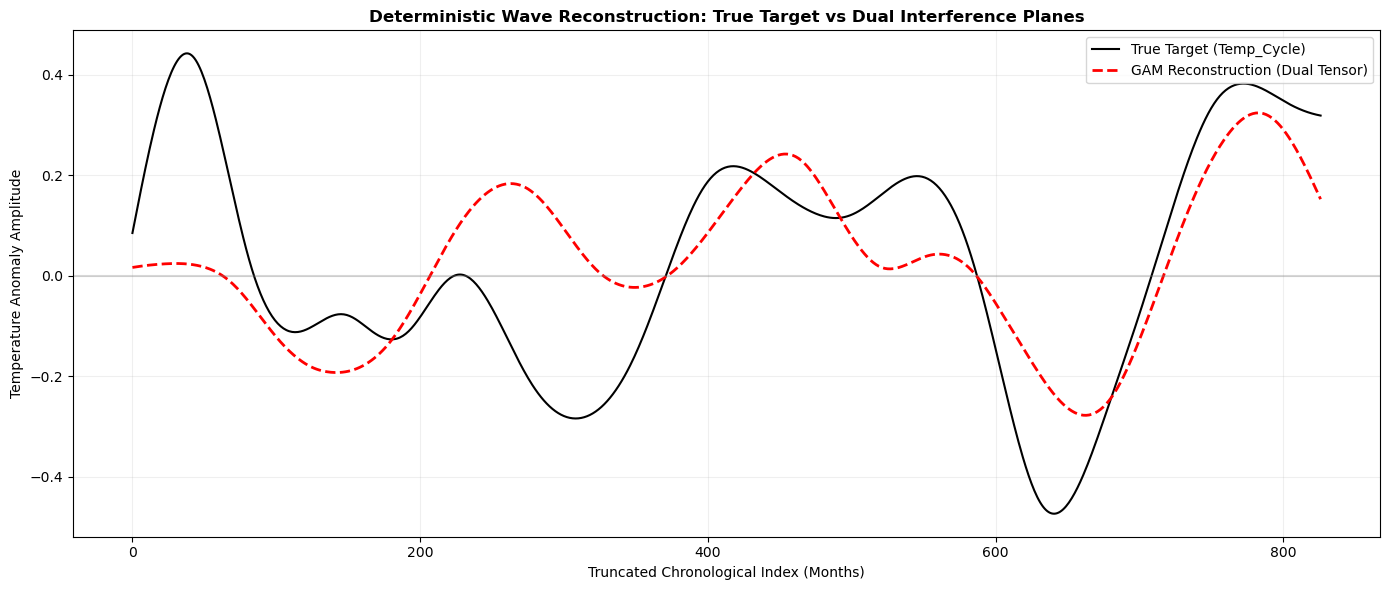

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pygam import LinearGAM, te
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Instantiate the optimal geometry
optimal_model = make_pipeline(StandardScaler(), LinearRegression())

# 2. Fit on the strictly truncated continuous matrix
print("Fitting final topological architecture on continuous matrix...")
shifted_features = []
static_matrix = df_gam_filtered[static_covariates].values[78:] if static_covariates else np.empty((len(y_base), 0))
for feature, lag in fixed_lag_dict.items():
    shifted_col = df_gam_filtered[feature].shift(lag).values[78:]
    shifted_features.append(shifted_col)
        
if shifted_features:
    X_matrix = np.column_stack([*shifted_features, static_matrix])
else:
    X_matrix = static_matrix
y_base = df_gam_filtered['Temp_Cycle'].values[78:]
optimal_model.fit(X_matrix, y_base)

# 3. Generate deterministic reconstruction
y_pred = optimal_model.predict(X_matrix)

# Compute final full-matrix metrics
final_rmse = np.sqrt(mean_squared_error(y_base, y_pred))
final_r2 = r2_score(y_base, y_pred)
print(f"Full Matrix Fit - RMSE: {final_rmse:.4f} | R2: {final_r2:.4f}")

# ==============================================================================
# VISUALIZATION 1: TEMPORAL RECONSTRUCTION
# ==============================================================================
plt.figure(figsize=(14, 6))

time_axis = np.arange(len(y_base))

plt.plot(time_axis, y_base, color='black', label='True Target (Temp_Cycle)', linewidth=1.5)
plt.plot(time_axis, y_pred, color='red', linestyle='--', label='GAM Reconstruction (Dual Tensor)', linewidth=2)

plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.title("Deterministic Wave Reconstruction: True Target vs Dual Interference Planes", fontweight='bold')
plt.xlabel("Truncated Chronological Index (Months)")
plt.ylabel("Temperature Anomaly Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [128]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from mpl_toolkits.mplot3d import Axes3D

# 1. Prepare the strictly truncated, lagged matrix
# Assuming X_matrix[:, 0] is NAO_Lagged and X_matrix[:, 1] is AMO_Lagged
X_df = pd.DataFrame(X_matrix[:, :2], columns=['NAO_Lagged', 'AMO_Lagged'])
y_series = pd.Series(y_base, name='Temp_Cycle')

# 2. Inject the intercept constant (\beta_0)
X_with_const = sm.add_constant(X_df)

# 3. Fit the exact OLS geometry
ols_model = sm.OLS(y_series, X_with_const).fit()
y_pred = ols_model.predict(X_with_const)

# 4. Output the complete econometric diagnostic
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Temp_Cycle   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     317.9
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          4.66e-103
Time:                        17:05:12   Log-Likelihood:                 282.47
No. Observations:                 827   AIC:                            -558.9
Df Residuals:                     824   BIC:                            -544.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0170      0.006      2.830      0.0

<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_365596/3942664835.py:26: SyntaxWarning: invalid escape sequence '\D'
  ax.set_zlabel('French Temp Cycle ($\Delta T$)')


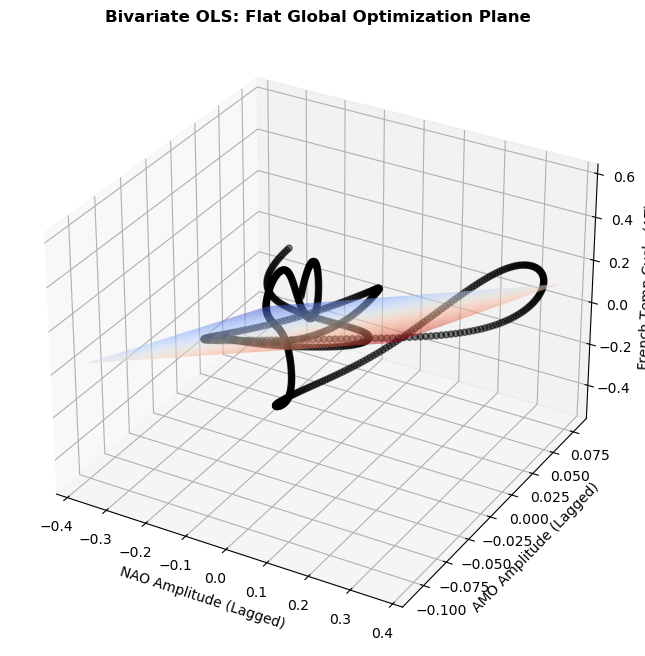

In [100]:
# Extract the exact coefficients
beta_0 = ols_model.params['const']
beta_1 = ols_model.params['NAO_Lagged']
beta_2 = ols_model.params['AMO_Lagged']

# Construct the mathematical meshgrid
x_surf, y_surf = np.meshgrid(
    np.linspace(X_df['NAO_Lagged'].min(), X_df['NAO_Lagged'].max(), 50),
    np.linspace(X_df['AMO_Lagged'].min(), X_df['AMO_Lagged'].max(), 50)
)
z_surf = beta_0 + (beta_1 * x_surf) + (beta_2 * y_surf)

# Render the 3D topology
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot true coordinates
ax.scatter(X_df['NAO_Lagged'], X_df['AMO_Lagged'], y_series, 
           c='black', marker='o', alpha=0.5, label='True Temperature Anomalies')

# Plot the linear tensor surface
ax.plot_surface(x_surf, y_surf, z_surf, cmap='coolwarm', alpha=0.6, edgecolor='none')

ax.set_xlabel('NAO Amplitude (Lagged)')
ax.set_ylabel('AMO Amplitude (Lagged)')
ax.set_zlabel('French Temp Cycle ($\Delta T$)')
ax.set_title('Bivariate OLS: Flat Global Optimization Plane', fontweight='bold')
plt.show()

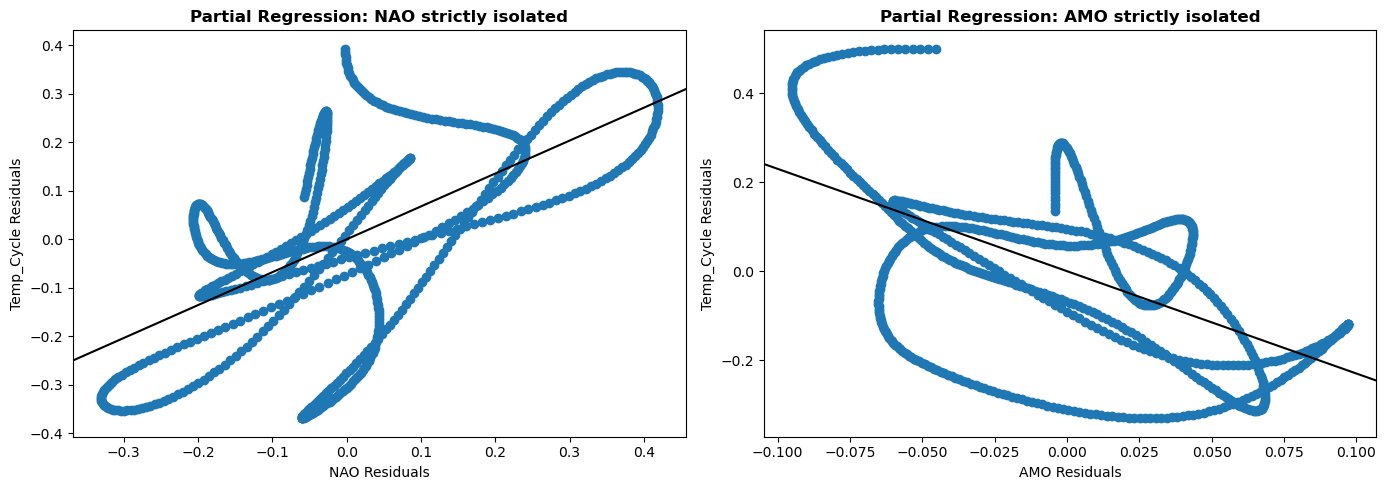

In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Partial regression for NAO
sm.graphics.plot_partregress(
    endog='Temp_Cycle', 
    exog_i='NAO_Lagged', 
    exog_others=['AMO_Lagged'], 
    data=pd.concat([y_series, X_df], axis=1), 
    obs_labels=False, 
    ax=ax1
)
ax1.set_title('Partial Regression: NAO strictly isolated', fontweight='bold')
ax1.set_xlabel('NAO Residuals')
ax1.set_ylabel('Temp_Cycle Residuals')

# Partial regression for AMO
sm.graphics.plot_partregress(
    endog='Temp_Cycle', 
    exog_i='AMO_Lagged', 
    exog_others=['NAO_Lagged'], 
    data=pd.concat([y_series, X_df], axis=1), 
    obs_labels=False, 
    ax=ax2
)
ax2.set_title('Partial Regression: AMO strictly isolated', fontweight='bold')
ax2.set_xlabel('AMO Residuals')
ax2.set_ylabel('Temp_Cycle Residuals')

plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_365596/372941131.py:10: SyntaxWarning: invalid escape sequence '\e'
  axes[0].set_ylabel('Residual Error ($\epsilon$)')
/tmp/ipykernel_365596/372941131.py:15: SyntaxWarning: invalid escape sequence '\e'
  axes[1].set_xlabel('Residual Error ($\epsilon$)')


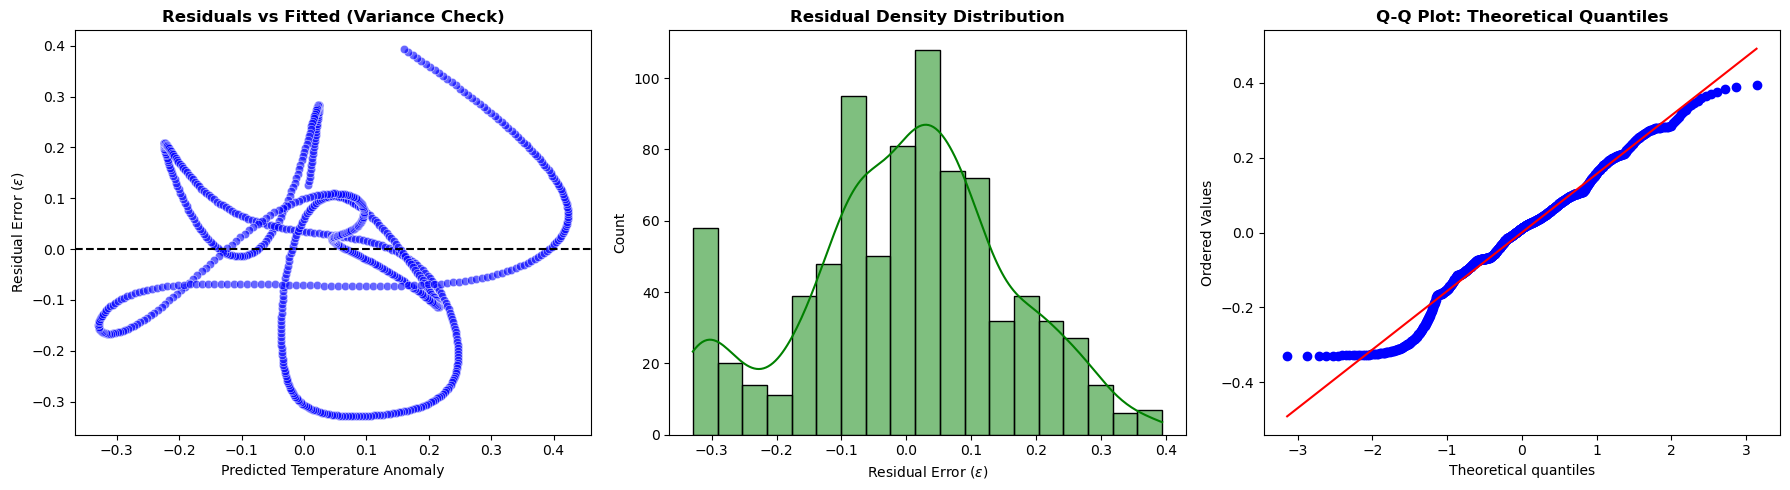

In [102]:
residuals = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Fitted (Test for Homoscedasticity and Non-linearity)
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], color='blue', alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals vs Fitted (Variance Check)', fontweight='bold')
axes[0].set_xlabel('Predicted Temperature Anomaly')
axes[0].set_ylabel('Residual Error ($\epsilon$)')

# 2. Residual Distribution (Test for Normality)
sns.histplot(residuals, kde=True, ax=axes[1], color='green')
axes[1].set_title('Residual Density Distribution', fontweight='bold')
axes[1].set_xlabel('Residual Error ($\epsilon$)')

# 3. Q-Q Plot (Test for Heavy Tails / Outliers)
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Theoretical Quantiles', fontweight='bold')

plt.tight_layout()
plt.show()

In [51]:
df_new = pd.DataFrame(data={"NAO" : nao_shifted, "AMO" : amo_shifted, "trend" : df_gam_filtered['Global_Warming'][max_lag_overall:],'Temp_Cycle' : df_gam_filtered['Temp_Cycle'][max_lag_overall:]})

optimal_formulation = amo_formulation

# Create a factory function for the model
gam_factory = lambda: LinearGAM(optimal_formulation, lam=20.0)

def grid_search_lags_cv(
    df: pd.DataFrame, 
    target_col: str, 
    lag_grid: dict, 
    static_features: list, 
    model_factory: callable, 
    n_splits: int = 5
) -> pd.DataFrame:
    """
    Evaluates different lag combinations for time-series features using K-Fold CV.
    
    Parameters:
    df (pd.DataFrame): The dataset containing all features and the target.
    target_col (str): The name of the target variable.
    lag_grid (dict): Dictionary mapping feature names to a list of integer lags to test.
                     e.g., {'NAO': [0, 60], 'EA': [160]}
    static_features (list): Features that should NOT be lagged (e.g., background trend).
    model_factory (callable): A function/lambda that returns a fresh, un-fitted model instance.
    n_splits (int): Number of K-Fold splits.
    
    Returns:
    pd.DataFrame: Ranked results sorted by Mean Out-of-Fold RMSE.
    """
    
    # 1. Determine the universal truncation limit to keep sample size constant
    max_lag_overall = max([max(lags) for lags in lag_grid.values()])
    print(f"Universal max lag limit set to: {max_lag_overall} steps.")
    
    # 2. Extract stationary base targets and static features
    y_base = df[target_col].values[max_lag_overall:]
    static_matrix = df[static_features].values[max_lag_overall:]
    
    # 3. Generate all permutations from the lag grid
    feature_names = list(lag_grid.keys())
    lag_combinations = list(itertools.product(*lag_grid.values()))
    
    # Initialize Time-Series safe K-Fold (no shuffling)
    kf = TimeSeriesSplit(n_splits=n_splits, test_size=len(y_base)//10)
    results = []
    
    total_tests = len(lag_combinations)
    print(f"Executing K-Fold CV across {total_tests} configurations...\n")
    
    # 4. Exhaustive Grid Search
    for idx, current_lags in enumerate(lag_combinations, 1):
        
        # Build the dynamic shifted feature matrix for this combination
        shifted_features = []
        for feature, lag in zip(feature_names, current_lags):
            shifted_col = df[feature].shift(lag).values[max_lag_overall:]
            shifted_features.append(shifted_col)
            
        # Combine shifted features with static features
        X_matrix = np.column_stack([*shifted_features, static_matrix])
        
        # K-Fold CV Loop
        fold_rmse = []
        fold_r2 = []
        
        for train_idx, test_idx in kf.split(X_matrix):
            X_train, X_test = X_matrix[train_idx], X_matrix[test_idx]
            y_train, y_test = y_base[train_idx], y_base[test_idx]
            
            # Instantiate a fresh model to prevent state leakage
            model = model_factory()
            
            try:
                # Fit and predict
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                
                # Calculate Out-of-Fold metrics
                fold_rmse.append(root_mean_squared_error(y_test, preds))
                fold_r2.append(r2_score(y_test, preds))
                
            except Exception as e:
                print(f"Fold failed for lags {current_lags}: {e}")
                fold_rmse.append(np.nan)
                fold_r2.append(np.nan)
        
        # Aggregate Results
        res_dict = {f"{feat}_Lag": lag for feat, lag in zip(feature_names, current_lags)}
        res_dict.update({
            "Mean_CV_RMSE": np.nanmean(fold_rmse),
            "Std_CV_RMSE": np.nanstd(fold_rmse),
            "Mean_CV_R2": np.nanmean(fold_r2)
        })
        results.append(res_dict)
        
        if idx % 20 == 0 or idx == total_tests:
            print(f"[{idx}/{total_tests}] Processed.")
            
    # 5. Format and Rank Output
    df_results = pd.DataFrame(results)
    df_ranked = df_results.sort_values(by="Mean_CV_RMSE", ascending=True).reset_index(drop=True)
    
    return df_ranked

ranked_results = grid_search_lags_cv(
    df=df_new,
    target_col='Temp_Cycle',
    lag_grid={"NAO": [0]},
    static_features=["AMO", 'trend'],
    model_factory=gam_factory,
    n_splits=5
)

print(ranked_results.head(10).to_string(index=False))

Universal max lag limit set to: 0 steps.
Executing K-Fold CV across 1 configurations...

[1/1] Processed.
 NAO_Lag  Mean_CV_RMSE  Std_CV_RMSE  Mean_CV_R2
       0      0.312798     0.095687   -1.182788


https://iopscience.iop.org/article/10.1088/1748-9326/aba925


Generating the 3D Bilinear Interaction Surface...


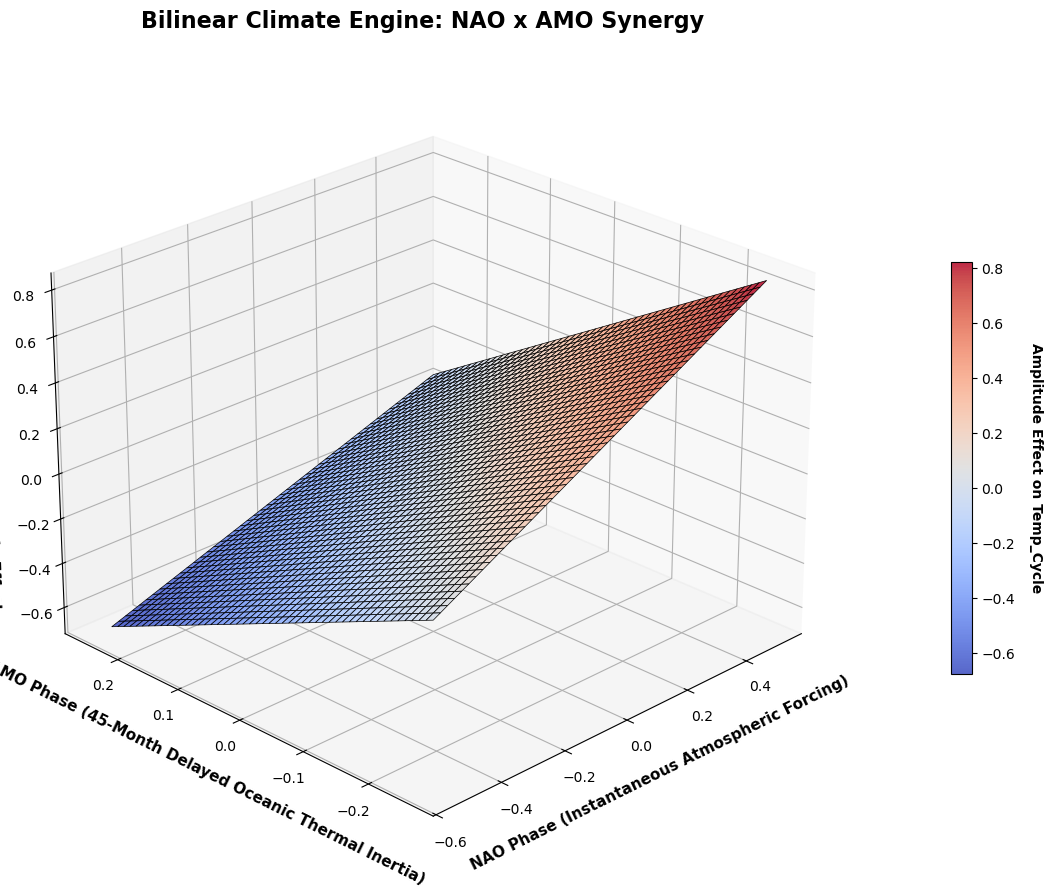

In [265]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from pygam import LinearGAM, te

# ==============================================================================
# 1. FIT THE OPTIMAL BILINEAR TENSOR MODEL
# ==============================================================================
# Assuming X_matrix_core is: Col 0 -> NAO (Lag 0), Col 1 -> AMO (Lag 45)
# We enforce spline_order=1 and n_splines=2 to create a strict bilinear surface
optimal_tensor_formulation = te(0, 1, spline_order=1, n_splines=[2, 2])

# Fit with your established penalization
final_model = LinearGAM(optimal_tensor_formulation, lam=50.0)
final_model.fit(X_matrix_core, y_base)

# ==============================================================================
# 2. FINAL VISUALIZATION: THE 3D CLIMATE INTERACTION ENGINE
# ==============================================================================
print("\nGenerating the 3D Bilinear Interaction Surface...")

# A. Generate a dense 50x50 coordinate grid across the physical ranges of NAO and AMO
XX_tensor = final_model.generate_X_grid(term=0, meshgrid=True, n=50)

# B. Extract the predicted temperature anomaly (Z-axis) across this grid
# FIX: Remove the tuple unpacking (`, _`). It returns a single 2D array.
Z_surface = final_model.partial_dependence(term=0, X=XX_tensor, meshgrid=True)

# C. Isolate the spatial axes directly from the tensor list
# FIX: Extract the 2D meshgrids directly
X_nao = XX_tensor[0]  # NAO Phase physical values
Y_amo = XX_tensor[1]  # AMO Phase physical values

# D. Construct the 3D Projection
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X_nao, Y_amo, Z_surface, 
                       cmap='coolwarm', 
                       edgecolor='black', 
                       linewidth=0.5, 
                       alpha=0.85)

# Formatting and Physical Labels
ax.set_title('Bilinear Climate Engine: NAO x AMO Synergy', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('\nNAO Phase (Instantaneous Atmospheric Forcing)', fontsize=11, fontweight='bold')
ax.set_ylabel('\nAMO Phase (45-Month Delayed Oceanic Thermal Inertia)', fontsize=11, fontweight='bold')
ax.set_zlabel('\nTarget Temperature Anomaly Effect', fontsize=11, fontweight='bold')

# Quantifiable Color Bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Amplitude Effect on Temp_Cycle', rotation=270, labelpad=20, fontweight='bold')

# Optimal viewing angle to expose the structural "twist" of the interaction
ax.view_init(elev=25, azim=225)

plt.tight_layout()
plt.show()

In [216]:
import numpy as np
baseline_std = np.std(df_gam_filtered['Temp_Cycle'].values[max_lag_overall:])
print(f"Global Target Standard Deviation: {baseline_std:.6f}")

Global Target Standard Deviation: 0.412763


In [184]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np

# 1. Initialize TimeSeriesSplit (Matching your previous setup)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# 2. Initialize Ridge Regression (Alpha is the L2 penalty, similar to GAM's lam)
ridge_model = Ridge(alpha=100.0)

fold_rmse = []
fold_r2 = []

print("-" * 50)
print("PURE LINEAR RIDGE REGRESSION CV (THE FINAL BASELINE)")
print("-" * 50)

for train_idx, test_idx in tscv.split(X_matrix_core):
    X_train, X_test = X_matrix_core[train_idx], X_matrix_core[test_idx]
    y_train, y_test = y_base[train_idx], y_base[test_idx]
    
    # Fit and Predict
    ridge_model.fit(X_train, y_train)
    preds = ridge_model.predict(X_test)
    
    # Calculate Metrics
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    fold_rmse.append(rmse)
    fold_r2.append(r2)
    
    print(f"Fold R2: {r2:8.4f} | RMSE: {rmse:8.4f}")

print("-" * 50)
print(f"Mean CV RMSE: {np.mean(fold_rmse):.4f}")
print(f"Mean CV R2:   {np.mean(fold_r2):.4f}")

--------------------------------------------------
PURE LINEAR RIDGE REGRESSION CV (THE FINAL BASELINE)
--------------------------------------------------
Fold R2:  -0.0557 | RMSE:   0.2641
Fold R2:  -0.2706 | RMSE:   0.5198
Fold R2:  -0.5566 | RMSE:   0.3111
Fold R2:  -0.2784 | RMSE:   0.4028
Fold R2:  -3.7273 | RMSE:   0.4708
--------------------------------------------------
Mean CV RMSE: 0.3937
Mean CV R2:   -0.9777


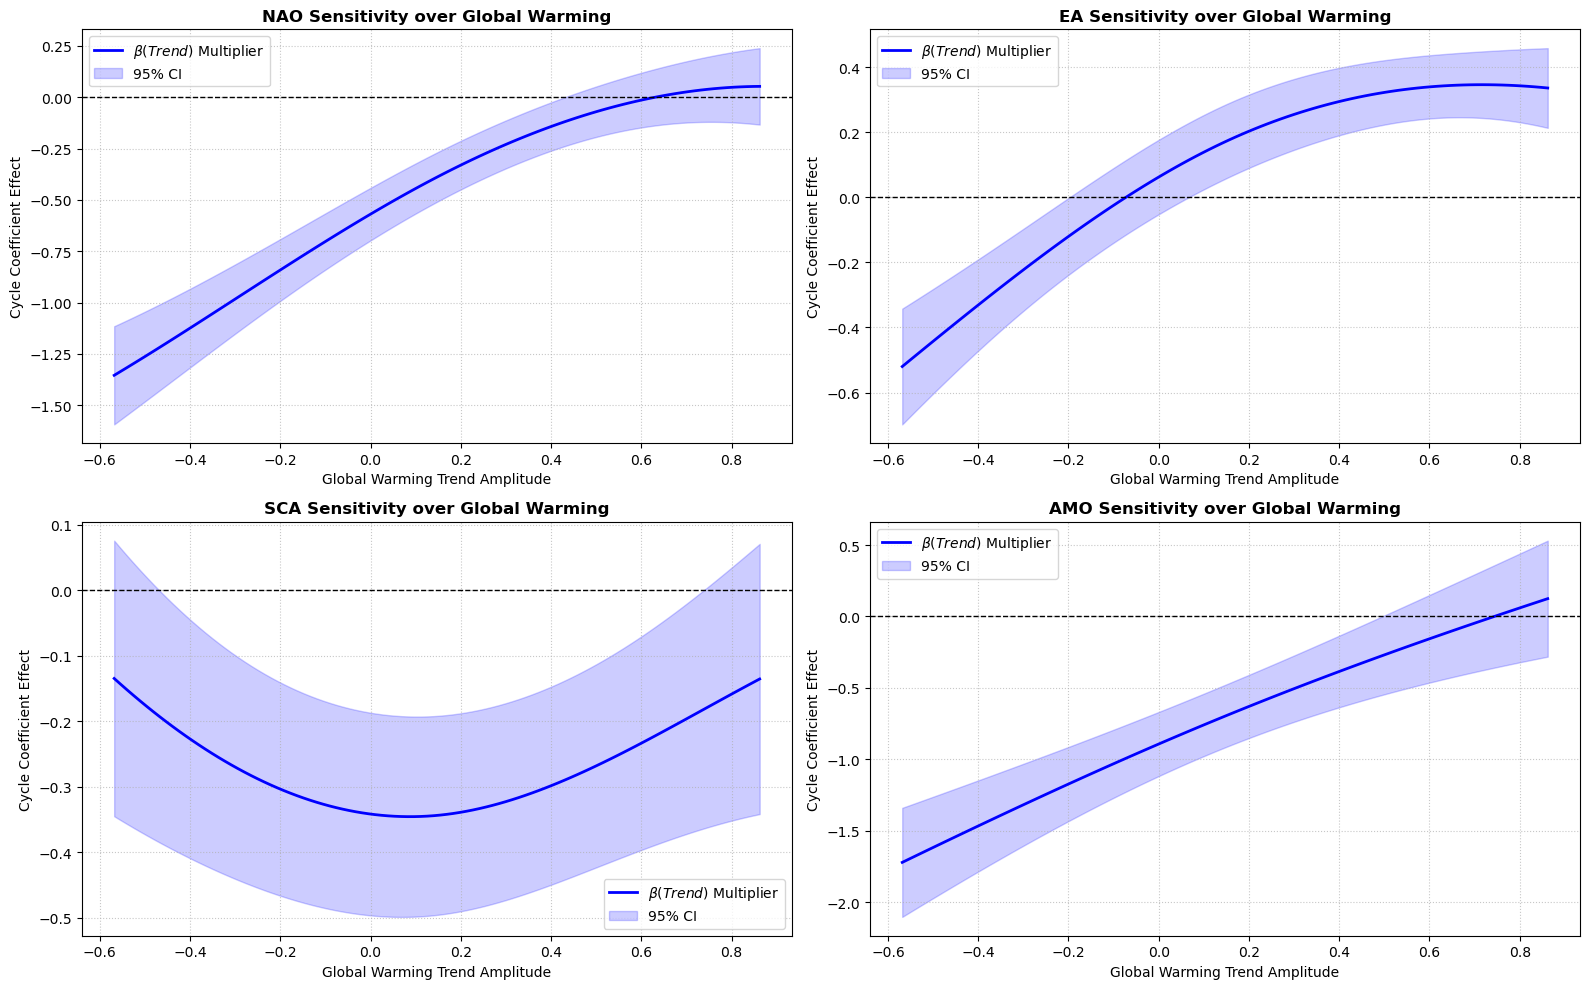

In [127]:
import matplotlib.pyplot as plt

# Define the exact term indices based on the architecture:
# l(0) [0], l(1) [1], l(2) [2], l(3) [3], s(4) [4]
# s(4, by=0) [5], s(4, by=1) [6], s(4, by=2) [7], s(4, by=3) [8]

interaction_terms = {
    'NAO Sensitivity': 5,
    'EA Sensitivity': 6,
    'SCA Sensitivity': 7,
    'AMO Sensitivity': 8
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (title, term_idx) in enumerate(interaction_terms.items()):
    ax = axes[idx]
    
    # Generate a dense grid strictly for the Trend variable (feature index 4)
    XX = best_model.generate_X_grid(term=term_idx)
    
    # Extract the partial dependence (the beta multiplier) and confidence intervals
    pdep, confi = best_model.partial_dependence(term=term_idx, X=XX, width=0.95)
    
    # XX[:, 4] isolates the Global Warming Trend values generated for the grid
    trend_grid = XX[:, 4]
    
    # Plotting
    ax.plot(trend_grid, pdep, color='blue', linewidth=2, label=r'$\beta(Trend)$ Multiplier')
    ax.fill_between(trend_grid, confi[:, 0], confi[:, 1], color='blue', alpha=0.2, label='95% CI')
    
    # Add a horizontal zero-line to identify phase inversions
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    
    ax.set_title(f'{title} over Global Warming', fontsize=12, fontweight='bold')
    ax.set_xlabel('Global Warming Trend Amplitude', fontsize=10)
    ax.set_ylabel(f'Cycle Coefficient Effect', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [107]:
import pandas as pd
from typing import List, Dict, Tuple

def engineer_time_series_features(
    df: pd.DataFrame, 
    lag_config: Dict[str, List[int]], 
    interaction_pairs: List[Tuple[str, str, str]]
) -> pd.DataFrame:
    """
    Expands a dataframe with specified lags and cross-feature interactions.
    
    Parameters:
    df (pd.DataFrame): Time-indexed dataframe.
    lag_config (Dict[str, List[int]]): Mapping of column names to lists of integer lags.
                                       e.g., {'price': [1, 2, 3], 'volume': [1, 5]}
    interaction_pairs (List[Tuple[str, str, str]]): List of tuples defining the interactions
                                                    (col_A, col_B, operation).
                                                    Valid operations: 'mul', 'add', 'div'.
    
    Returns:
    pd.DataFrame: DataFrame containing the original and newly engineered features.
    """
    df_expanded = df.copy()
    
    # 1. Generate Multiple Lags
    for feature, lags in lag_config.items():
        if feature not in df.columns:
            raise KeyError(f"Feature '{feature}' not found in DataFrame.")
            
        for lag in lags:
            lagged_col_name = f"{feature}_lag_{lag}"
            df_expanded[lagged_col_name] = df_expanded[feature].shift(lag)
            
    # 2. Generate Non-Independent Relations
    for col1, col2, op in interaction_pairs:
        if col1 not in df_expanded.columns or col2 not in df_expanded.columns:
            raise KeyError(f"Interaction features '{col1}' or '{col2}' not found.")
            
        interaction_name = f"{col1}_{op}_{col2}"
        
        if op == 'mul':
            df_expanded[interaction_name] = df_expanded[col1] * df_expanded[col2]
        elif op == 'add':
            df_expanded[interaction_name] = df_expanded[col1] + df_expanded[col2]
        elif op == 'div':
            # Replaces 0 with NaN to prevent ZeroDivisionError propagation into inf
            df_expanded[interaction_name] = df_expanded[col1] / df_expanded[col2].replace(0, pd.NA)
        else:
            raise ValueError(f"Unsupported operation: '{op}'")
            
    return df_expanded

# Example execution parameters:
# lag_config = {
#     'feature_A': [1, 2, 4],
#     'feature_B': [1, 12]
# }
# interaction_pairs = [
#     ('feature_A_lag_1', 'feature_B_lag_1', 'mul'), 
#     ('feature_A_lag_4', 'feature_A', 'div')       
# ]

In [98]:
import pandas as pd

# ==============================================================================
# 1. APPLYING THE TEMPORAL SHIFTS (LAGS)
# ==============================================================================
# We create a copy to avoid altering the original extracted cycles
df_predictive = df_gam_filtered.copy()

# The Atmospheric predictors operate concurrently (Lag 0), so we leave them alone.
# df_predictive['NAO_Cycle'] = df_gam_filtered['NAO_Cycle']
# df_predictive['EA_Cycle']  = df_gam_filtered['EA_Cycle']
# df_predictive['SCA_Cycle'] = df_gam_filtered['SCA_Cycle']

# The Oceanic predictor must be shifted FORWARD to align its past with the present target.
# A shift of +160 means the AMO value from row 0 is pushed down to row 160.


# ==============================================================================
# 2. MATRIX ALIGNMENT
# ==============================================================================
# Shifting arrays creates missing data (NaNs) at the beginning of the dataset.
# The first 160 months of the target variable no longer have a corresponding AMO history.
# We must drop these rows to ensure the GAM receives a complete, dense matrix.
df_predictive = df_predictive.dropna()

# ==============================================================================
# 3. DEFINING THE FINAL FEATURE TENSOR
# ==============================================================================
# Re-extract the aligned arrays
y_final = df_predictive['Temp_Cycle'].values

# The feature matrix X is now perfectly phase-aligned based on physical causality
X_final = df_predictive[['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle', 'Global_Warming']].values

In [99]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION (CONCURRENT STRICT)
# ==============================================================================
# IMPORTANT: Ensure X_final is an np.column_stack of all 5 arrays
X_concurrent = X_final
y_concurrent = y_final

# Index 0: NAO_Cycle (Concurrent)
# Index 1: EA_Cycle (Concurrent)
# Index 2: SCA_Cycle (Concurrent)
# Index 3: AMO_Cycle (Lagged or Concurrent based on your X_final construction)
# Index 4: Background_Trend (CEEMDAN Residual)

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
architectures = {
    # Baselines + Background Trend
    "1. Strictly Linear (Additive)": l(0) + l(1) + l(2) + l(3) + s(4, spline_order=2),
    "2. Independent Splines (Non-Linear Additive)": s(0, spline_order=2) + s(1, spline_order=2) + s(2, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # 2-Way Atmospheric Interactions + Independent Ocean + Background Trend
    "3. Interaction: [NAO x EA] + Splines(SCA, AMO)": te(0, 1, n_splines=(2, 2), spline_order=1) + s(2, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    "4. Interaction: [NAO x SCA] + Splines(EA, AMO)": te(0, 2, n_splines=(2, 2), spline_order=1) + s(1, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    "5. Interaction: [EA x SCA] + Splines(NAO, AMO)": te(1, 2, n_splines=(2, 2), spline_order=1) + s(0, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # 3-Way Atmospheric Tensors + Independent Ocean + Background Trend
    "6. 3-Way Atmospheric Tensor + Linear AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + l(3) + s(4, spline_order=2),
    "7. 3-Way Atmospheric Tensor + Spline AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # Fully Coupled 4-Dimensional Interaction + Background Trend
    "8. Full 4-Way Tensor (Atmosphere x Ocean)": te(0, 1, 2, 3, n_splines=(2, 2, 2, 2), spline_order=1) + s(4, spline_order=2)
    
}
architectures2 = {
    # -------------------------------------------------------------------------
    # CONTROL: The baseline we established (Trend is purely an additive intercept)
    "1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS A: The Trend only modulates the Ocean's heat release. 
    # The Atmosphere distributes it normally.
    "2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS B: The Trend modulates the Atmosphere INDIVIDUALLY.
    # The pressure networks are independent of each other, but dependent on the warming era.
    "3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]": 
        te(0, 4, n_splines=(3, 3), spline_order=2) + te(1, 4, n_splines=(3, 3), spline_order=2) + te(2, 4, n_splines=(3, 3), spline_order=2) + l(3),

    # -------------------------------------------------------------------------
    # HYPOTHESIS C: The Trend modulates the specific 2-Way atmospheric couplings.
    "4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)": 
        te(0, 1, 4, n_splines=(2, 2, 2), spline_order=1) + s(2, spline_order=2) + l(3),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS D: The Trend modulates the ENTIRE 3D atmospheric boundary layer.
    # The tri-pole behaves fundamentally differently in a hotter world.
    "5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean": 
        te(0, 1, 2, 4, n_splines=(2, 2, 2, 2), spline_order=1) + l(3),
        
    # -------------------------------------------------------------------------
    # HYPOTHESIS E: Total System Coupling (The absolute limit of PyGAM math).
    # Everything interacts with everything, shifting dynamically with global warming.
    "6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]": 
        te(0, 1, 2, 3, 4, n_splines=(2, 2, 2, 2, 2), spline_order=1)
}
# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS
# ==============================================================================
results = []

print(f"Executing Exhaustive Concurrent GAM Test on {len(X_concurrent)} rows with 5 Dimensions...")

for name, formulation in architectures2.items():
    try:
        model = LinearGAM(formulation)
        model.gridsearch(X_concurrent, y_concurrent, progress=False)
        
        results.append({
            "Architecture": name,
            "AIC": model.statistics_['AIC'],
            "GCV": model.statistics_['GCV'],
            "EDOF": model.statistics_['edof'],
            "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
        })
    except Exception as e:
        results.append({
            "Architecture": name,
            "AIC": float('inf'),
            "GCV": float('inf'),
            "EDOF": 0,
            "Pseudo R-Squared": 0.0
        })
        print(f"Failed on {name}: {e}")

# ==============================================================================
# 4. OUTPUT
# ==============================================================================
df_results = pd.DataFrame(results).sort_values(by="AIC")

print("\n========================================================================================")
print("ARCHITECTURE PERFORMANCE RANKING (ANCHORED TREND)")
print("========================================================================================")
print(df_results.to_string(index=False))

Executing Exhaustive Concurrent GAM Test on 905 rows with 5 Dimensions...

ARCHITECTURE PERFORMANCE RANKING (ANCHORED TREND)
                                                                Architecture          AIC      GCV      EDOF  Pseudo R-Squared
                   1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend -3916.796446 0.000795 32.473415          0.985105
                    6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend] -2011.096087 0.006525 31.999850          0.877537
3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend] -1756.819022 0.008532 18.981026          0.833004
                             2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere -1669.260027 0.009474 27.124123          0.819363
           5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean -1405.021393 0.012562 16.937372          0.752538
         4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO) -1195.462168 0.015962 25.239080     

In [87]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION
# ==============================================================================
# Index 0: NAO_Cycle 
# Index 1: EA_Cycle 
# Index 2: SCA_Cycle 
# Index 3: AMO_Lagged (160 Months)
# Index 4: Background_Trend (CEEMDAN Residual)

X_concurrent = X_final
y_concurrent = y_final

# ==============================================================================
# 2. TREND-DEPENDENT ARCHITECTURE DEFINITIONS
# ==============================================================================
architectures = {
    # -------------------------------------------------------------------------
    # CONTROL: The baseline we established (Trend is purely an additive intercept)
    "1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS A: The Trend only modulates the Ocean's heat release. 
    # The Atmosphere distributes it normally.
    "2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS B: The Trend modulates the Atmosphere INDIVIDUALLY.
    # The pressure networks are independent of each other, but dependent on the warming era.
    "3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]": 
        te(0, 4, n_splines=(3, 3), spline_order=2) + te(1, 4, n_splines=(3, 3), spline_order=2) + te(2, 4, n_splines=(3, 3), spline_order=2) + l(3),

    # -------------------------------------------------------------------------
    # HYPOTHESIS C: The Trend modulates the specific 2-Way atmospheric couplings.
    "4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)": 
        te(0, 1, 4, n_splines=(2, 2, 2), spline_order=1) + s(2, spline_order=2) + l(3),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS D: The Trend modulates the ENTIRE 3D atmospheric boundary layer.
    # The tri-pole behaves fundamentally differently in a hotter world.
    "5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean": 
        te(0, 1, 2, 4, n_splines=(2, 2, 2, 2), spline_order=1) + l(3),
        
    # -------------------------------------------------------------------------
    # HYPOTHESIS E: Total System Coupling (The absolute limit of PyGAM math).
    # Everything interacts with everything, shifting dynamically with global warming.
    "6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]": 
        te(0, 1, 2, 3, 4, n_splines=(2, 2, 2, 2, 2), spline_order=1)
}

# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS (Using 5-Fold Walk-Forward Validation)
# ==============================================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

print(f"Executing Walk-Forward Validation on Trend-Dependent Architectures...")

for name, formulation in architectures.items():
    print(f"Testing: {name}")
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_concurrent), 1):
        X_train, X_test = X_concurrent[train_index], X_concurrent[test_index]
        y_train, y_test = y_concurrent[train_index], y_concurrent[test_index]

        model = LinearGAM(formulation)
        
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': r2
            })
        except Exception as e:
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': np.nan
            })

df_folds = pd.DataFrame(fold_metrics)
df_summary = df_folds.groupby('Architecture')['R2'].mean().sort_values(ascending=False).reset_index()

print("\n===========================================================")
print("TREND-DEPENDENT OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)")
print("===========================================================")
print(df_summary.to_string(index=False))

Executing Walk-Forward Validation on Trend-Dependent Architectures...
Testing: 1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend
Testing: 2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere
Testing: 3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]
Testing: 4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)
Testing: 5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean
Testing: 6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]

TREND-DEPENDENT OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)
                                                                Architecture           R2
                             2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere   -99.752978
                   1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend  -103.352609
         4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)  -634.333999
3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]  -681.

In [73]:
np.mean(df_climate['EA'])

np.float64(-0.1309060773480663)

In [65]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION (CONCURRENT STRICT)
# ==============================================================================
# We use the clean, un-shifted CEEMDAN DataFrame.
# Drop any existing NaNs just to ensure matrix integrity.
df_concurrent = df_gam_filtered.dropna()

# Index 0: NAO_Cycle (Concurrent)
# Index 1: EA_Cycle (Concurrent)
# Index 2: SCA_Cycle (Concurrent)
# Index 3: AMO_Cycle (Concurrent)
X_concurrent = X_final
y_concurrent = y_final

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
# We constrain the tensors (n_splines) to prevent the EDOF from exploding past 30-40,
# ensuring we test general physics rather than overfitting the exact time series.

architectures = {
    # Baselines
    "1. Strictly Linear (Additive)": l(0) + l(1) + l(2) + l(3),
    "2. Independent Splines (Non-Linear Additive)": s(0, spline_order=2) + s(1, spline_order=2) + s(2, spline_order=2) + s(3, spline_order=2),
    
    # 2-Way Atmospheric Interactions + Independent Ocean
    "3. Interaction: [NAO x EA] + Splines(SCA, AMO)": te(0, 1, n_splines=(2, 2), spline_order=1) + s(2, spline_order=2) + s(3, spline_order=2),
    "4. Interaction: [NAO x SCA] + Splines(EA, AMO)": te(0, 2, n_splines=(2, 2), spline_order=1) + s(1, spline_order=2) + s(3, spline_order=2),
    "5. Interaction: [EA x SCA] + Splines(NAO, AMO)": te(1, 2, n_splines=(2, 2), spline_order=1) + s(0, spline_order=2) + s(3, spline_order=2),
    
    # 3-Way Atmospheric Tensors + Independent Ocean
    "6. 3-Way Atmospheric Tensor + Linear AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + l(3),
    "7. 3-Way Atmospheric Tensor + Spline AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + s(3, spline_order=2),
    
    # Fully Coupled 4-Dimensional Interaction (Highly Constrained)
    "8. Full 4-Way Tensor (Atmosphere x Ocean)": te(0, 1, 2, 3, n_splines=(2, 2, 2, 2), spline_order=1)
}

# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS
# ==============================================================================
results = []

print(f"Executing Exhaustive Concurrent GAM Test on {len(X_concurrent)} rows...")

for name, formulation in architectures.items():
    try:
        model = LinearGAM(formulation)
        model.gridsearch(X_concurrent, y_concurrent, progress=False)
        
        results.append({
            "Architecture": name,
            "AIC": model.statistics_['AIC'],
            "GCV": model.statistics_['GCV'],
            "EDOF": model.statistics_['edof'],
            "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
        })
    except Exception as e:
        # Failsafe in case a specific tensor constraint collapses the solver
        results.append({
            "Architecture": name,
            "AIC": float('inf'),
            "GCV": float('inf'),
            "EDOF": 0,
            "Pseudo R-Squared": 0.0
        })
        print(f"Failed on {name}: {e}")

# ==============================================================================
# 4. OUTPUT
# ==============================================================================
df_results = pd.DataFrame(results).sort_values(by="AIC")

print("\n========================================================================================")
print("CONCURRENT ARCHITECTURE PERFORMANCE RANKING")
print("========================================================================================")
print(df_results.to_string(index=False))

Executing Exhaustive Concurrent GAM Test on 905 rows...

CONCURRENT ARCHITECTURE PERFORMANCE RANKING
                                  Architecture          AIC      GCV      EDOF  Pseudo R-Squared
  2. Independent Splines (Non-Linear Additive) -1271.379780 0.015454 73.110053          0.974307
3. Interaction: [NAO x EA] + Splines(SCA, AMO)  -234.512228 0.046741 37.796608          0.912422
4. Interaction: [NAO x SCA] + Splines(EA, AMO)  -106.794250 0.053829 37.869704          0.899164
5. Interaction: [EA x SCA] + Splines(NAO, AMO)   -45.846239 0.057396 34.760827          0.891380
      7. 3-Way Atmospheric Tensor + Spline AMO   134.094628 0.069367 25.331188          0.864648
     8. Full 4-Way Tensor (Atmosphere x Ocean)   281.374012 0.080898 15.999994          0.837369
      6. 3-Way Atmospheric Tensor + Linear AMO   590.210778 0.113061  8.994277          0.767630
                 1. Strictly Linear (Additive)   602.199312 0.114144  4.908828          0.762388


Training Observations: 724
Testing Observations:  181

--- OUT-OF-SAMPLE DIAGNOSTICS ---
Out-of-Sample R-Squared: -15.2317
Out-of-Sample MSE:       1.5240


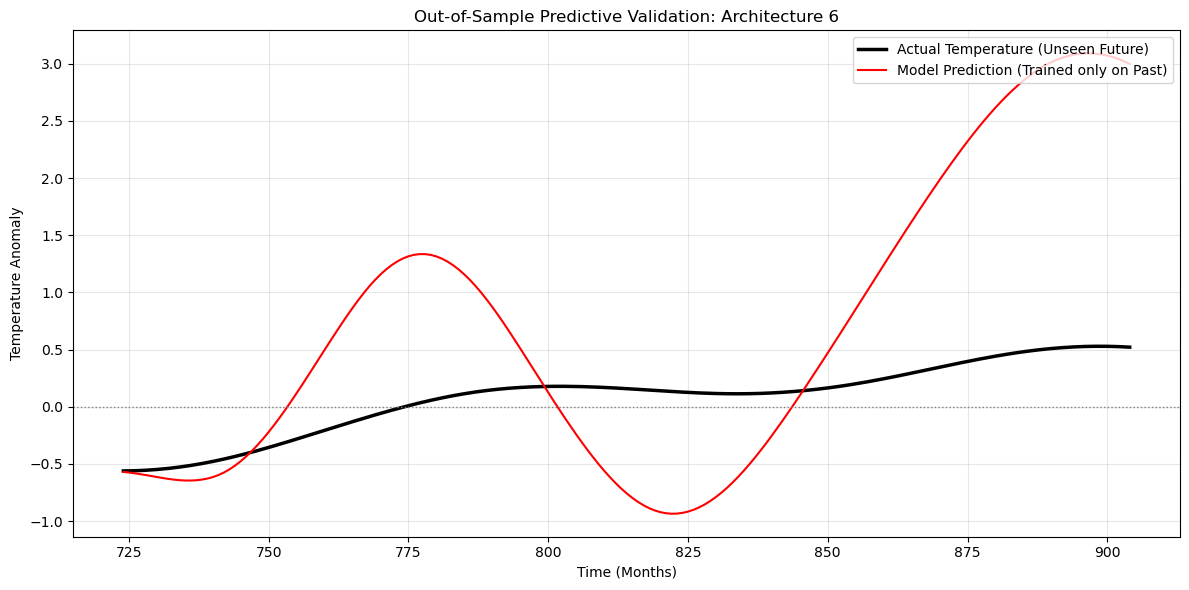

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, te, l
from sklearn.metrics import r2_score, mean_squared_error

# ==============================================================================
# 1. TIME-SERIES CHRONOLOGICAL SPLIT (80% Train / 20% Test)
# ==============================================================================
# We CANNOT use random cross-validation on time series due to autocorrelation.
# We must split chronologically.

split_index = int(len(X_concurrent) * 0.80)

# Training Data (The Past: e.g., 1950 to ~2010)
X_train = X_concurrent[:split_index]
y_train = y_concurrent[:split_index]

# Testing Data (The Future: e.g., ~2010 to 2025)
X_test = X_concurrent[split_index:]
y_test = y_concurrent[split_index:]

print(f"Training Observations: {len(X_train)}")
print(f"Testing Observations:  {len(X_test)}")

# ==============================================================================
# 2. ISOLATED TRAINING
# ==============================================================================
# Fit Architecture 6 STRICTLY on the training subset
validation_model = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2))
validation_model.gridsearch(X_train, y_train, progress=False)

# ==============================================================================
# 3. BLIND PREDICTION & METRICS
# ==============================================================================
# Force the model to predict the test set (which it has never seen)
y_pred_test = validation_model.predict(X_test)

# Calculate Out-of-Sample R-Squared and MSE
# Using sklearn's r2_score for standard out-of-sample evaluation
out_of_sample_r2 = r2_score(y_test, y_pred_test)
out_of_sample_mse = mean_squared_error(y_test, y_pred_test)

print(f"\n--- OUT-OF-SAMPLE DIAGNOSTICS ---")
print(f"Out-of-Sample R-Squared: {out_of_sample_r2:.4f}")
print(f"Out-of-Sample MSE:       {out_of_sample_mse:.4f}")

# ==============================================================================
# 4. VISUAL VALIDATION
# ==============================================================================
plt.figure(figsize=(12, 6))

# Create a continuous time axis for plotting
time_test = np.arange(split_index, len(y_concurrent))

plt.plot(time_test, y_test, color='black', linewidth=2.5, label='Actual Temperature (Unseen Future)')
plt.plot(time_test, y_pred_test, color='red', linewidth=1.5, label='Model Prediction (Trained only on Past)')

plt.title('Out-of-Sample Predictive Validation: Architecture 6')
plt.xlabel('Time (Months)')
plt.ylabel('Temperature Anomaly')
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd
from pygam import LinearGAM

# Define the number of folds (5 folds for decadal data)
tscv = TimeSeriesSplit(n_splits=5)

fold_metrics = []

# CORRECT UNPACKING: Separate the string name from the PyGAM formulation
for name, formulation in architectures.items():
    print(f"Testing Architecture: {name}...")
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_final), 1):
        # Split the data chronologically
        X_train, X_test = X_final[train_index], X_final[test_index]
        y_train, y_test = y_final[train_index], y_final[test_index]

        # Instantiate the model with the isolated TermList
        model = LinearGAM(formulation)
        
        try:
            # Fit and Predict
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Calculate Metrics
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': r2,
                'MSE': mse
            })
        except Exception as e:
            # PyGAM splines can occasionally fail to fit on the very first 
            # fold if the training sample is too small. We catch that here.
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': np.nan,
                'MSE': np.nan
            })

# Compile the raw fold data
df_folds = pd.DataFrame(fold_metrics)

# Calculate the mean Out-of-Sample R2 across all 5 folds to find the definitive winner
df_summary = df_folds.groupby('Architecture')['R2'].mean().sort_values(ascending=False).reset_index()

print("\n===========================================================")
print("CROSS-VALIDATED OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)")
print("===========================================================")
print(df_summary.to_string(index=False))

Testing Architecture: 1. Strictly Linear (Additive)...
Testing Architecture: 2. Independent Splines (Non-Linear Additive)...
Testing Architecture: 3. Interaction: [NAO x EA] + Splines(SCA, AMO)...
Testing Architecture: 4. Interaction: [NAO x SCA] + Splines(EA, AMO)...
Testing Architecture: 5. Interaction: [EA x SCA] + Splines(NAO, AMO)...
Testing Architecture: 6. 3-Way Atmospheric Tensor + Linear AMO...
Testing Architecture: 7. 3-Way Atmospheric Tensor + Spline AMO...
Testing Architecture: 8. Full 4-Way Tensor (Atmosphere x Ocean)...

CROSS-VALIDATED OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)
                                  Architecture           R2
                 1. Strictly Linear (Additive)   -73.905687
4. Interaction: [NAO x SCA] + Splines(EA, AMO)  -517.951555
5. Interaction: [EA x SCA] + Splines(NAO, AMO)  -535.942926
      6. 3-Way Atmospheric Tensor + Linear AMO  -750.596363
  2. Independent Splines (Non-Linear Additive)  -919.530952
3. Interaction: [NAO x EA] + Splines(SCA,

Historical Epoch R-Squared: 0.7185


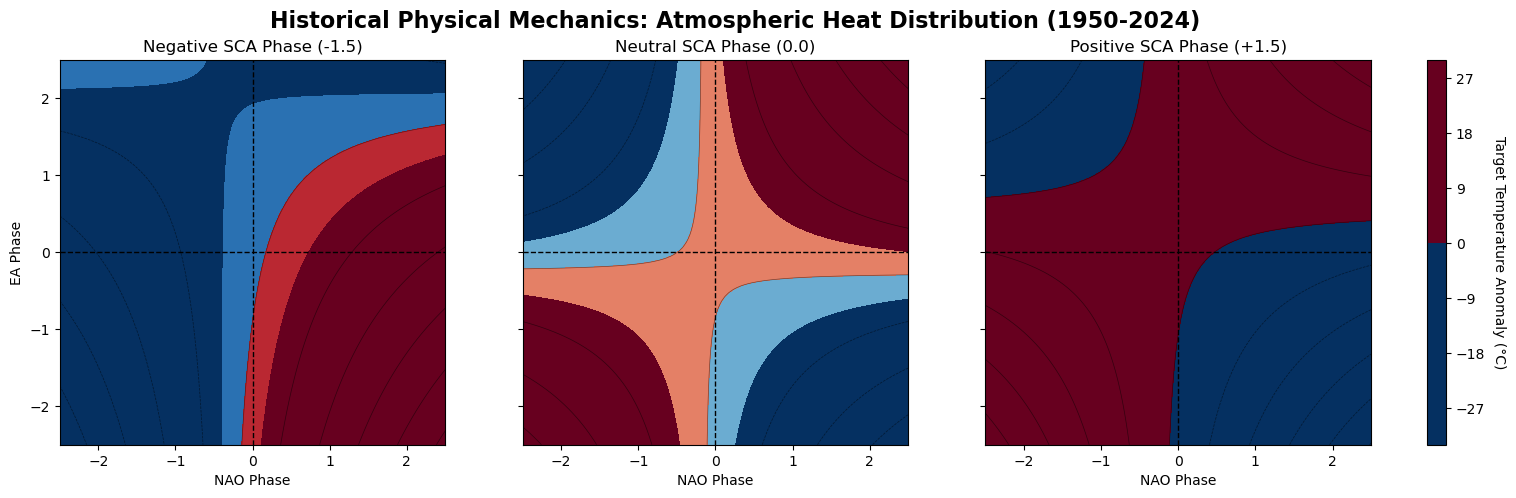

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, te, l, s

# ==============================================================================
# 1. FIT THE EPOCHAL MODEL (1950 - 2024)
# ==============================================================================
# We use the full matrix to map the complete historical epoch.
# Index 0: NAO, 1: EA, 2: SCA, 3: AMO_Lagged, 4: Background_Trend
model = LinearGAM(
    te(0, 1, 2, n_splines=(4, 4, 4)) + l(3) + s(4, spline_order=2)
)
model.fit(X_final, y_final)

print(f"Historical Epoch R-Squared: {model.statistics_['pseudo_r2']['explained_deviance']:.4f}")

# ==============================================================================
# 2. SYNTHESIZE THE PHASE SPACE
# ==============================================================================
# To visualize a 3D interaction (NAO x EA x SCA), we must look at 2D slices.
# We will create a grid of NAO and EA combinations, and view them under 
# three different "regimes" of the Scandinavian Blocking pattern (SCA).

# Define the grid boundaries (typically -2.5 to +2.5 standard deviations)
nao_range = np.linspace(-2.5, 2.5, 100)
ea_range = np.linspace(-2.5, 2.5, 100)

# Create the 2D meshgrid
NAO_grid, EA_grid = np.meshgrid(nao_range, ea_range)

# Flatten the grids for PyGAM prediction
NAO_flat = NAO_grid.flatten()
EA_flat = EA_grid.flatten()

# Freeze the slow-moving baselines at zero (neutral ocean, neutral trend)
# This isolates the pure atmospheric physics.
AMO_neutral = np.zeros_like(NAO_flat)
Trend_neutral = np.zeros_like(NAO_flat)

# Define the three SCA phases to test
sca_phases = {
    "Negative SCA Phase (-1.5)": -1.5,
    "Neutral SCA Phase (0.0)": 0.0,
    "Positive SCA Phase (+1.5)": 1.5
}

# ==============================================================================
# 3. VISUALIZE THE THERMODYNAMIC MECHANICS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Historical Physical Mechanics: Atmospheric Heat Distribution (1950-2024)', fontsize=16, fontweight='bold')

for ax, (title, sca_val) in zip(axes, sca_phases.items()):
    
    # Create the SCA array for this specific slice
    SCA_flat = np.full_like(NAO_flat, sca_val)
    
    # Assemble the synthetic feature matrix
    X_synthetic = np.column_stack((NAO_flat, EA_flat, SCA_flat, AMO_neutral, Trend_neutral))
    
    # Predict the thermal anomaly for this specific grid
    Temp_pred = model.predict(X_synthetic)
    
    # Reshape back to 2D for contour plotting
    Temp_grid = Temp_pred.reshape(100, 100)
    
    # Plot the heat map (Contour)
    contour = ax.contourf(NAO_grid, EA_grid, Temp_grid, levels=20, cmap='RdBu_r', vmin=-1.0, vmax=1.0)
    ax.contour(NAO_grid, EA_grid, Temp_grid, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    
    ax.set_title(title)
    ax.set_xlabel('NAO Phase')
    if ax == axes[0]:
        ax.set_ylabel('EA Phase')
    
    # Add crosshairs for the neutral (0,0) center
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

# Add a shared colorbar
cbar = fig.colorbar(contour, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
cbar.set_label('Target Temperature Anomaly (°C)', rotation=270, labelpad=15)

plt.show()

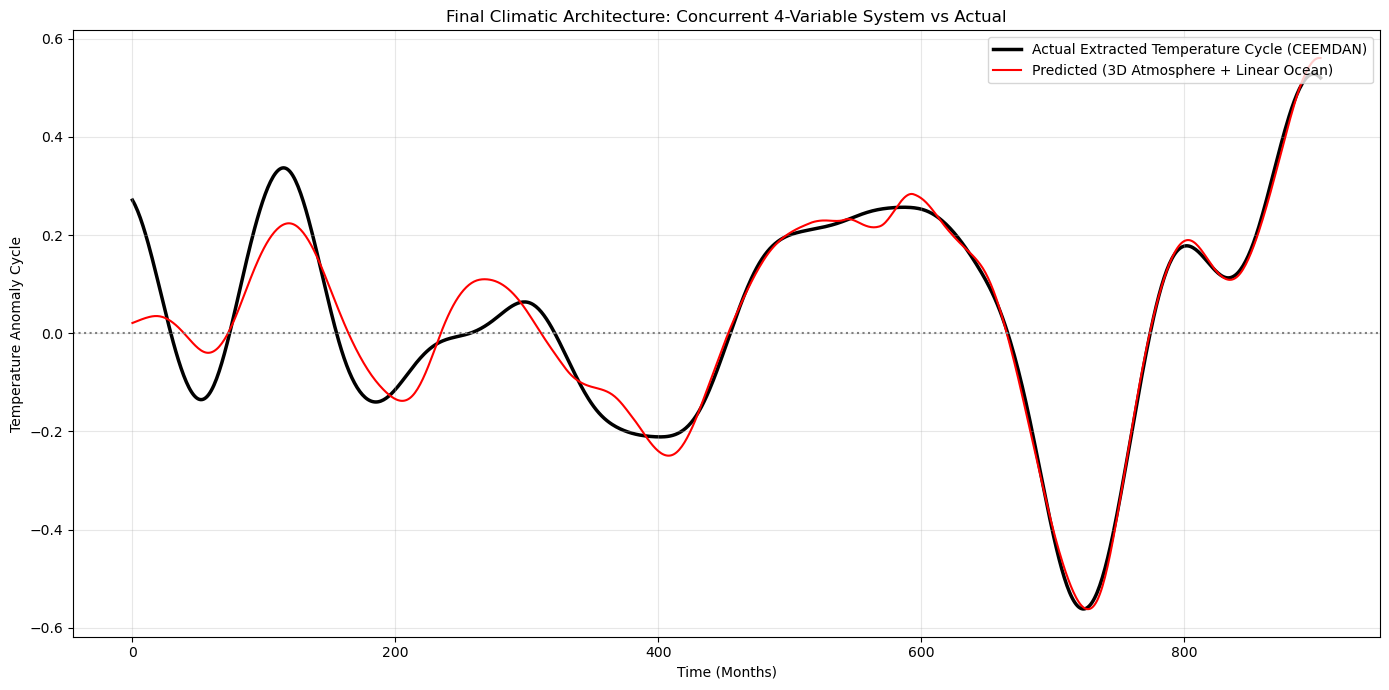

Final Model Mean Squared Error: 0.0024


In [102]:
import matplotlib.pyplot as plt

# Instantiate and fit the optimal architecture
# Index 0: NAO, Index 1: EA, Index 2: SCA, Index 3: AMO
final_concurrent_model = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2))
final_concurrent_model.fit(X_concurrent, y_concurrent)

# Generate predictions
y_pred_final = final_concurrent_model.predict(X_concurrent)

# Plot the Final Verification
plt.figure(figsize=(14, 7))

plt.plot(y_concurrent, color='black', linewidth=2.5, label='Actual Extracted Temperature Cycle (CEEMDAN)', zorder=1)
plt.plot(y_pred_final, color='red', linewidth=1.5, label='Predicted (3D Atmosphere + Linear Ocean)', zorder=2)

plt.title('Final Climatic Architecture: Concurrent 4-Variable System vs Actual')
plt.xlabel('Time (Months)')
plt.ylabel('Temperature Anomaly Cycle')
plt.axhline(0, color='gray', linestyle=':', linewidth=1.5)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final Error Metric
mse_final = np.nanmean((y_concurrent - y_pred_final)**2)
print(f"Final Model Mean Squared Error: {mse_final:.4f}")

In [120]:
df_gam_filtered= df_gam_filtered.drop(columns="test")

In [108]:
df_gam_filtered['AMO_Cycle']

Date
1950-01-01   -0.03
1950-02-01   -0.13
1950-03-01   -0.16
1950-04-01   -0.22
1950-05-01   -0.23
              ... 
2025-01-01    0.98
2025-02-01    0.86
2025-03-01    0.75
2025-04-01    0.67
2025-05-01    0.73
Name: AMO_Cycle, Length: 905, dtype: float64

In [96]:
df_amo[2]

0     -0.03
1     -0.13
2     -0.16
3     -0.22
4     -0.23
       ... 
907    0.83
908    0.76
909    1.01
910    0.96
911    0.75
Name: 2, Length: 912, dtype: float64

In [21]:
from pygam import LinearGAM, te, l, s

# We force a low-resolution tensor grid. 
# n_splines=(5, 5, 5) limits the basis functions for each dimension.
architectures_constrained = {
    # The unrestricted winner (for direct baseline comparison)
    "Unrestricted 3-Way Tensor": te(0, 1, 2),
    
    # Constrained 3-Way Tensors
    "Constrained 3-Way (5 nodes)": te(0, 1, 2, n_splines=(5, 5, 5)),
    "Constrained 3-Way (4 nodes)": te(0, 1, 2, n_splines=(4, 4, 4)),
    
    # Constrained 2-Way Tensors with Linear Baseline
    "Constrained 2-Way (NAO & EA) + Linear Lag": te(0, 2, n_splines=(6, 6)) + l(1),
    
    # The purely linear baseline (to ensure the restricted tensors still outperform it)
    "Linear Baseline": l(0) + l(1) + l(2)
}

results_constrained = []

for name, formulation in architectures_constrained.items():
    model = LinearGAM(formulation)
    model.gridsearch(X, y, progress=False)
    
    results_constrained.append({
        "Architecture": name,
        "AIC": model.statistics_['AIC'],
        "GCV": model.statistics_['GCV'],
        "EDOF": model.statistics_['edof'],
        "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
    })

df_constrained = pd.DataFrame(results_constrained).sort_values(by="AIC")
print(df_constrained.to_string(index=False))

                             Architecture        AIC      GCV       EDOF  Pseudo R-Squared
                Unrestricted 3-Way Tensor 332.267466 0.104665 114.786017          0.612492
              Constrained 3-Way (5 nodes) 592.798317 0.129320  29.064896          0.316594
              Constrained 3-Way (4 nodes) 647.036489 0.136445  14.894419          0.239557
Constrained 2-Way (NAO & EA) + Linear Lag 647.414753 0.137710  22.669170          0.254446
                          Linear Baseline 725.709803 0.149218   3.960025          0.134358


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Instantiate and fit the winning architecture
# Index 0: NAO, Index 1: NAO_Lag135, Index 2: EA
final_gam = LinearGAM(te(0, 2) + l(1))
final_gam.gridsearch(X, y, progress=False)

# Generate a 2D grid for the tensor term (term=0 corresponds to te(0, 2))
# This creates a meshgrid of the NAO (feature 0) and EA (feature 2)
XX = final_gam.generate_X_grid(term=0, n=100)

# Calculate the partial dependence (the isolated temperature impact)
Z = final_gam.partial_dependence(term=0, X=XX)

# Reshape the output for contour plotting
x_nao = XX[:, 0].reshape(100, 100)
y_ea = XX[:, 2].reshape(100, 100)
z_temp = Z.reshape(100, 100)

# Plot the Interaction Surface
plt.figure(figsize=(10, 8))
contour = plt.contourf(x_nao, y_ea, z_temp, levels=50, cmap='coolwarm')
plt.colorbar(contour, label='Partial Dependence: Target Temperature Impact')

# Formatting
plt.title('NAO & EA Coupled Interaction Manifold')
plt.xlabel('North Atlantic Oscillation (NAO) Z-Score')
plt.ylabel('East Atlantic Pattern (EA) Z-Score')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# Output the coefficient for the strictly linear 135-month gyre lag (term 1)
gyre_coef = final_gam.coef_[-2] # Second to last coefficient is the linear term, last is intercept
print(f"Linear Gyre Forcing Coefficient (Lag 135): {gyre_coef:.5f}")

ValueError: term requires feature 2, but X has only 2 dimensions

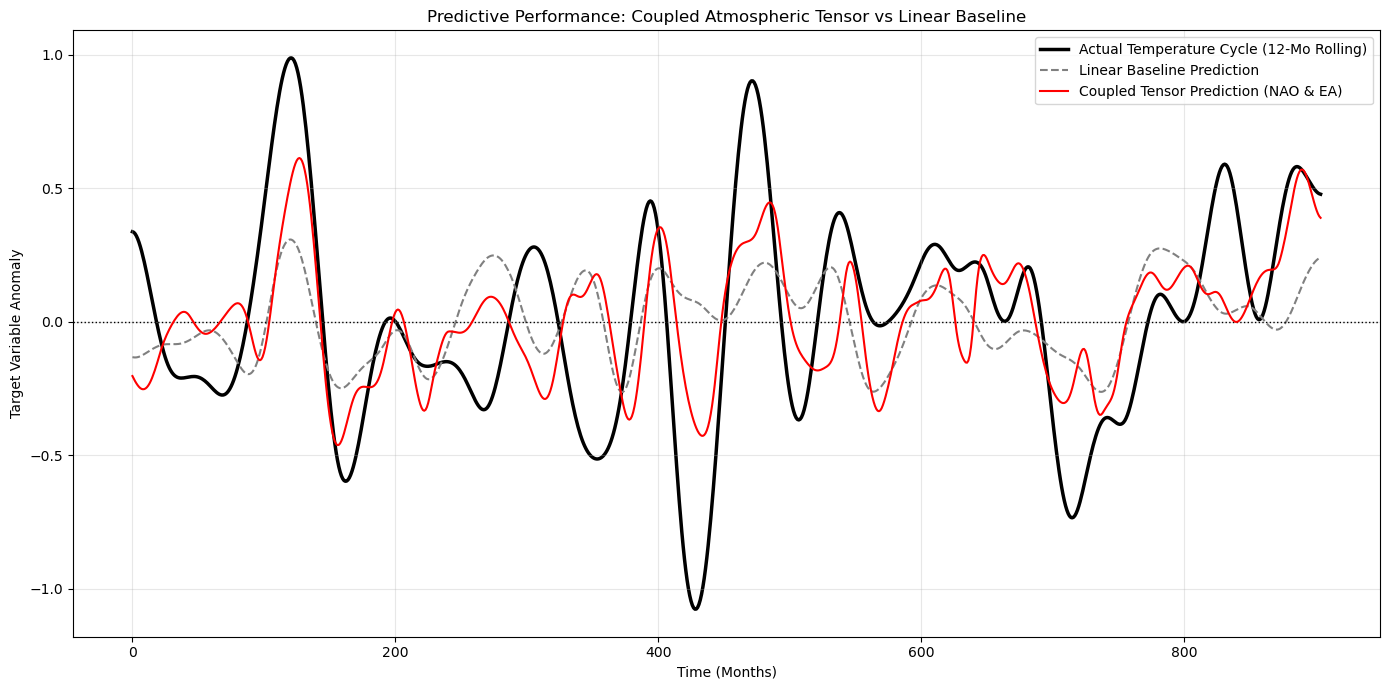

MSE (Linear Baseline vs Cycle): 0.1290
MSE (Tensor Model vs Cycle):    0.0903


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, l, te

# ==============================================================================
# 1. MODEL INSTANTIATION AND PREDICTION
# ==============================================================================
# Ensure your feature matrix X (NAO, NAO_Lag135, EA) and target y are loaded.
# Re-instantiate and fit the two competing models
X= X_final
y= y_final
model_linear = LinearGAM(l(0) + l(1) + l(2))
model_linear.fit(X, y)

model_tensor = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2))
model_tensor.fit(X, y)

# Generate the predicted arrays
y_pred_linear = model_linear.predict(X)
y_pred_tensor = model_tensor.predict(X)

# ==============================================================================
# 2. ISOLATING THE TARGET CYCLE
# ==============================================================================
# To plot "against the cycles", we calculate a 12-month moving average of the 
# actual temperature to filter out high-frequency noise and reveal the base cycle.
# (Alternatively, you can replace 'y_cycle' directly with your CEEMDAN IMF 5 array)
y_series = pd.Series(y)
y_cycle = y

# ==============================================================================
# 3. PLOTTING THE COMPARISON
# ==============================================================================
# Create a time array (assuming monthly data, length matches y)
time_axis = np.arange(len(y))

plt.figure(figsize=(14, 7))

# Plot 1: The underlying physical cycle (Smoothed Actuals or IMF)
plt.plot(time_axis, y_cycle, color='black', linewidth=2.5, label='Actual Temperature Cycle (12-Mo Rolling)', zorder=1)

# Plot 2: The Linear Baseline Prediction
plt.plot(time_axis, y_pred_linear, color='gray', linestyle='--', linewidth=1.5, label='Linear Baseline Prediction', zorder=2)

# Plot 3: The Tensor Interaction Prediction
plt.plot(time_axis, y_pred_tensor, color='red', linewidth=1.5, label='Coupled Tensor Prediction (NAO & EA)', zorder=3)

# Formatting the plot
plt.title('Predictive Performance: Coupled Atmospheric Tensor vs Linear Baseline')
plt.xlabel('Time (Months)')
plt.ylabel('Target Variable Anomaly')
plt.axhline(0, color='black', linestyle=':', linewidth=1)

# Optional: Zoom in on a specific 20-year window to see the exact divergence
# plt.xlim(200, 440) 

plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. RESIDUAL CALCULATION (Optional Diagnostic)
# ==============================================================================
# Calculate the Mean Squared Error against the cycle to quantify the visual gap
mse_linear = np.nanmean((y_cycle - y_pred_linear)**2)
mse_tensor = np.nanmean((y_cycle - y_pred_tensor)**2)

print(f"MSE (Linear Baseline vs Cycle): {mse_linear:.4f}")
print(f"MSE (Tensor Model vs Cycle):    {mse_tensor:.4f}")